In [1]:
# Setup paths and load libraries
path_to_lucas <- "../../data/reproduce_lucas_wflow"
directory_path <- "../../"

suppressMessages({
    library(SummarizedExperiment)
    library(magrittr)
    library(stringr)
    library(tidyverse)
    library(grid)
    library(lemon)
    library(gridExtra)
    library(cowplot)
    library(data.table)
    library(pROC)
    library(RColorBrewer)
    library(here)
    library(rlucas)
    library(ggsci)
})

source(file.path(path_to_lucas, "code/plot-roc.r"))
data(se, package="rlucas")
rename <- dplyr::rename

In [2]:
metadata <- colData(se) %>% as_tibble()
meta_mica <- read_csv(file.path(directory_path, "data/mica_meta.csv"), show_col_types=FALSE)

load(file.path(directory_path, "models_code/FINAL/train_preds_lucas_c1_FULL.rda"))

# Set to TRUE to show the grey vertical line at 0.80 specificity in ROC curves
SHOW_SPECIFICITY_LINE <- FALSE

## Prepare Model Data

In [3]:
model_levels <- c("DELFI", "Proteomics", "DELFI-Pro Lung")

prepare_model_data <- function(preds, score_col, model_name, metadata) {
    preds %>%
        filter(!is.na(!!sym(score_col))) %>%
        select(id, !!sym(score_col)) %>%
        set_colnames(c("pgdx_id", "score")) %>%
        mutate(training_model = model_name) %>%
        left_join(metadata %>% select(lab_id, pgdx_id), by = "pgdx_id") %>%
        select(-pgdx_id) %>%
        select(lab_id, everything())
}

dat1 <- prepare_model_data(preds, "score.seq", model_levels[1], metadata)
dat2 <- prepare_model_data(preds, "score.olink.only", model_levels[2], metadata)
dat3 <- prepare_model_data(preds, "score.seq.olink", model_levels[3], metadata)

dat <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels))

combined <- fig3_data(se, dat1, dat2, dat3)

performance_at_cutoff <- function(x, cutoff) {
    robj <- pROC::roc(class ~ score, x, ret = TRUE, quiet = TRUE)
    tibble(sens = robj$sens, spec = robj$spec, thresholds = robj$thresholds) %>%
        filter(thresholds >= cutoff) %>%
        arrange(thresholds) %>%
        slice(1)
}

In [4]:
nocancer_labels <- c("no baseline cancer", "benign",
                     "no lung cancer, other cancer",
                     "no lung cancer, later lung cancer")

clindat <- fig3_clindat(se)

overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
           class = factor(class, c("No cancer", "Cancer")))

overall.list <- split(overall, overall$training_model)

In [5]:
load(file.path(directory_path, "models_code/FINAL/calibration_set_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_val_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_preds_lucas_c1_FULL.rda"))

In [6]:
# Quantile mapping corrects technical batch shift between LUCAS and MICA. The
# mapping is learned from non-cancer samples only:
#   Reference: LUCAS training CV predictions (via dat1/dat2/dat3)
#   Source:    MICA calibration set (preds_mica_cal) — all healthy
# After calibration MICA scores are on the LUCAS scale, so one LUCAS-derived
# threshold applies uniformly.

lucas_train_nocancer <- bind_rows(dat1, dat2, dat3) %>%
    left_join(clindat, by = "lab_id") %>%
    filter(patient_type %in% nocancer_labels)

lucas_nocancer_seq       <- lucas_train_nocancer %>% filter(training_model == model_levels[1]) %>% pull(score)
lucas_nocancer_olink     <- lucas_train_nocancer %>% filter(training_model == model_levels[2]) %>% pull(score)
lucas_nocancer_seq_olink <- lucas_train_nocancer %>% filter(training_model == model_levels[3]) %>% pull(score)

mica_cal_nocancer <- preds_mica_cal

build_quantile_mapper <- function(source_scores, reference_scores, n_quantiles = 500) {
    probs <- seq(0, 1, length.out = n_quantiles)
    source_q <- quantile(source_scores, probs = probs, na.rm = TRUE)
    ref_q    <- quantile(reference_scores, probs = probs, na.rm = TRUE)
    function(new_scores) {
        approx(x = source_q, y = ref_q, xout = new_scores, rule = 2)$y
    }
}

mapper_seq <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.test,
    reference_scores = lucas_nocancer_seq
)
mapper_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.olink.only.test,
    reference_scores = lucas_nocancer_olink
)
mapper_seq_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.olink.test,
    reference_scores = lucas_nocancer_seq_olink
)

cat("Quantile mappers built from:\n")
cat("  LUCAS training non-cancer:", length(lucas_nocancer_seq), "samples\n")
cat("  MICA calibration non-cancer:", nrow(mica_cal_nocancer), "samples\n\n")

# ---- LUCAS test set ----------------------------------------------------
lucas_val <- preds_test %>%
    left_join(metadata %>% select(lab_id, pgdx_id), by = c("id" = "pgdx_id")) %>%
    left_join(clindat %>% select(lab_id, patient_type, stage), by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "LUCAS",
        score.seq       = score.seq.test,
        score.olink     = score.olink.only.test,
        score.seq.olink = score.seq.olink.test
    ) %>%
    select(id, lab_id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

# ---- calibrated MICA validation set ------------------------------------
mica_val <- preds_mica_validation %>%
    select(-any_of(c("type", "Stage", "stage"))) %>%
    left_join(
        meta_mica %>% select(id, type, Stage) %>%
            mutate(type = as.character(type), Stage = as.character(Stage)),
        by = "id"
    ) %>%
    mutate(
        class = ifelse(type == "healthy", "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage = Stage,
        stage_combined = case_when(
            Stage %in% c("I", "II")   ~ "I/II",
            Stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "MICA",
        score.seq       = mapper_seq(score.seq.test),
        score.olink     = mapper_olink(score.olink.only.test),
        score.seq.olink = mapper_seq_olink(score.seq.olink.test)
    ) %>%
    select(id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

combined_val <- bind_rows(lucas_val, mica_val)

cat("Combined validation set:\n")
cat("  LUCAS:", nrow(lucas_val), "samples\n")
cat("  MICA: ", nrow(mica_val),  "samples\n")
cat("  Total:", nrow(combined_val), "samples\n\n")

combined_val %>% count(cohort, class) %>%
    pivot_wider(names_from = class, values_from = n) %>% print()

combined_val %>% filter(class == "Cancer") %>%
    count(cohort, stage_combined) %>%
    pivot_wider(names_from = stage_combined, values_from = n, values_fill = 0) %>% print()

Quantile mappers built from:
  LUCAS training non-cancer: 84 samples
  MICA calibration non-cancer: 40 samples

Combined validation set:
  LUCAS: 65 samples
  MICA:  360 samples
  Total: 425 samples

# A tibble: 2 × 3
  cohort `No cancer` Cancer
  <chr>        <int>  <int>
1 LUCAS           40     25
2 MICA           344     16
# A tibble: 2 × 3
  cohort `I/II` `III/IV`
  <chr>   <int>    <int>
1 LUCAS       5       20
2 MICA        3       13


In [7]:
# =============================================================================
# Combined validation figure with locked LUCAS training thresholds
# =============================================================================
create_combined_validation_figure <- function(
    combined_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80),
    models_to_plot = c("DELFI", "DELFI-Pro"),
    validation_set = "combined",
    se_level = 0.95,
    plot_width = 12,
    plot_height = 12
) {

    # ── Validate inputs ──────────────────────────────────────────────────
    valid_val_options <- c("combined", "lucas_test", "mica")
    if (!all(validation_set %in% valid_val_options)) {
        stop(paste("Invalid validation_set option(s). Valid options are:",
                   paste(valid_val_options, collapse = ", ")))
    }

    # ── Facet label formatter (single source of truth) ──────────────────
    spec_label <- function(cutoff) paste0("Spec. ", round(cutoff * 100), "%")

    # ── Model configuration ──────────────────────────────────────────────
    model_map <- list(
        "DELFI" = list(
            idx = 1, dat = dat1,
            score_col = "score.seq",
            display_name = "DELFI"
        ),
        "Proteomics" = list(
            idx = 2, dat = dat2,
            score_col = "score.olink",
            display_name = "Proteomics"
        ),
        "DELFI-Pro" = list(
            idx = 3, dat = dat3,
            score_col = "score.seq.olink",
            display_name = "DELFI-Pro"
        )
    )

    valid_models <- names(model_map)
    if (!all(models_to_plot %in% valid_models)) {
        stop(paste("Invalid model name(s). Valid options are:",
                   paste(valid_models, collapse = ", ")))
    }

    n_cutoffs <- length(specificity_cutoffs)
    n_models  <- length(models_to_plot)
    if (is.null(plot_height)) {
        plot_height <- max(8, n_cutoffs * 3 + 1)
    }

    alpha          <- 1 - se_level
    lower_quantile <- alpha / 2
    upper_quantile <- 1 - alpha / 2

    # ── Helper: clean a validation subset ───────────────────────────────
    clean_val <- function(df) {
        df %>%
            mutate(
                stage_combined = case_when(
                    class == "No cancer"              ~ NA_character_,
                    stage_combined %in% "I/II"        ~ "I/II",
                    stage_combined %in% "III/IV"      ~ "III/IV",
                    TRUE                              ~ NA_character_
                )
            )
    }

    # ── Build validation set list ────────────────────────────────────────
    val_sets <- list()
    if ("combined" %in% validation_set) {
        val_sets[["Combined (LUCAS test + MICA)"]] <- clean_val(combined_val)
    }
    if ("lucas_test" %in% validation_set) {
        val_sets[["Test (LUCAS)"]] <- combined_val %>%
            filter(cohort == "LUCAS") %>%
            clean_val()
    }
    if ("mica" %in% validation_set) {
        val_sets[["Validation (MICA)"]] <- combined_val %>%
            filter(cohort == "MICA") %>%
            clean_val()
    }

    cat("Datasets to evaluate:\n")
    cat("  Training (LUCAS): used for threshold derivation + shown in plot\n")
    for (nm in names(val_sets)) {
        d <- val_sets[[nm]]
        cat(sprintf("  %s: %d samples (%d no cancer, %d cancer)\n",
                    nm, nrow(d),
                    sum(d$class == "No cancer"), sum(d$class == "Cancer")))
    }
    cat("\n")

    # ── LUCAS training data (for threshold derivation ONLY) ──────────────
    overall <- bind_rows(dat1, dat2, dat3) %>%
        mutate(training_model = factor(training_model, model_levels)) %>%
        left_join(clindat, by = "lab_id") %>%
        mutate(
            class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
            class = factor(class, c("No cancer", "Cancer")),
            stage_combined = case_when(
                stage %in% c("I", "II")   ~ "I/II",
                stage %in% c("III", "IV") ~ "III/IV",
                TRUE                      ~ NA_character_
            )
        )
    overall.list <- split(overall, overall$training_model)

    # ── Helper: evaluate a dataset at a locked threshold ─────────────────
    evaluate_at_threshold <- function(data, score_col, threshold,
                                      lower_q, upper_q) {

        conf_level <- 2 * upper_q - 1

        scores <- data %>%
            select(class, stage = stage_combined, score = !!sym(score_col)) %>%
            filter(!is.na(score))

        # Specificity
        nocancer <- scores %>% filter(class == "No cancer")
        n_nc     <- nrow(nocancer)
        tn       <- sum(nocancer$score < threshold)
        spec_ci  <- prop.test(tn, n_nc, conf.level = conf_level, correct = FALSE)

        # Sensitivity by stage
        stage_perf <- scores %>%
            filter(class == "Cancer", !is.na(stage)) %>%
            group_by(stage) %>%
            summarise(n = n(), tp = sum(score >= threshold), .groups = "drop") %>%
            rowwise() %>%
            mutate(
                ci    = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE)),
                sens  = ci$estimate,
                lower = ci$conf.int[1],
                upper = ci$conf.int[2]
            ) %>%
            select(-ci) %>%
            ungroup()

        bind_rows(
            tibble(
                stage = "0", value = unname(spec_ci$estimate), n = n_nc,
                lower = spec_ci$conf.int[1], upper = spec_ci$conf.int[2],
                statistic = "Specificity"
            ),
            stage_perf %>% transmute(
                stage, value = sens, n,
                lower, upper,
                statistic = "Sensitivity"
            )
        )
    }

    # ── Main loop ────────────────────────────────────────────────────────
    all_perf <- list()

    for (spec_cutoff in specificity_cutoffs) {
        for (model_name in models_to_plot) {
            model_info <- model_map[[model_name]]

            # ── Lock threshold from LUCAS TRAINING ROC ───────────────────
            lucas_roc_data <- overall.list[[model_info$idx]] %>%
                select(score, class)
            tmp <- pROC::roc(class ~ score, data = lucas_roc_data,
                             ret = TRUE, quiet = TRUE)
            cutoff_row <- tibble(
                sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
            ) %>%
                filter(spec >= spec_cutoff) %>%
                arrange(spec) %>%
                slice(1)
            locked_threshold <- cutoff_row$thresholds

            # ── Evaluate on LUCAS training set ───────────────────────────
            train_data <- overall.list[[model_info$idx]]
            train_perf <- evaluate_at_threshold(
                train_data, "score", locked_threshold,
                lower_quantile, upper_quantile
            ) %>% mutate(dataset = "Training (LUCAS)")

            all_perf[[paste(spec_cutoff, model_name, "train", sep = "_")]] <- train_perf %>%
                mutate(
                    model              = model_info$display_name,
                    specificity_cutoff = spec_cutoff,
                    specificity_label  = spec_label(spec_cutoff),
                    locked_threshold   = locked_threshold
                )

            # ── Evaluate on each selected validation set ─────────────────
            for (val_name in names(val_sets)) {
                val_perf <- evaluate_at_threshold(
                    val_sets[[val_name]], model_info$score_col, locked_threshold,
                    lower_quantile, upper_quantile
                ) %>% mutate(dataset = val_name)

                all_perf[[paste(spec_cutoff, model_name, val_name, sep = "_")]] <- val_perf %>%
                    mutate(
                        model              = model_info$display_name,
                        specificity_cutoff = spec_cutoff,
                        specificity_label  = spec_label(spec_cutoff),
                        locked_threshold   = locked_threshold
                    )
            }
        }
    }

    # ── Combine all results ──────────────────────────────────────────────
    model_display_levels <- sapply(models_to_plot, function(m) model_map[[m]]$display_name)
    dataset_levels <- c("Training (LUCAS)", names(val_sets))

    combined_perf <- bind_rows(all_perf) %>%
        mutate(
            dataset = factor(dataset, levels = dataset_levels),
            stage = factor(stage, c("0", "I/II", "III/IV")),
            statistic = factor(statistic, c("Specificity", "Sensitivity")),
            specificity_label = factor(
                specificity_label,
                levels = spec_label(sort(specificity_cutoffs))
            ),
            model  = factor(model, levels = model_display_levels),
            stage0 = as.character(stage),
            stage0 = ifelse(stage0 == "0", "Non-Cancer", stage0),
            stage0 = factor(stage0, c("Non-Cancer", "I/II", "III/IV"))
        )

    # ── X-axis labels ────────────────────────────────────────────────────
    if (n_models == 1) {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ as.character(stage0)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ 1,
                    TRUE ~ as.numeric(stage0)
                )
            )
    } else {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ paste0(stage0, "\n", model)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ as.numeric(model),
                    TRUE ~ as.numeric(stage0) * 100 + as.numeric(model)
                )
            )
    }

    spec_levels <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    sens_levels <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    spec_perf <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        mutate(x_label = factor(x_label, levels = spec_levels))

    sens_perf <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        mutate(x_label = factor(x_label, levels = sens_levels))

    # ── N labels: only for the highest specificity facet ────────────────
    highest_spec_label <- spec_label(max(specificity_cutoffs))

    spec_N <- spec_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    sens_N <- sens_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    # ── Reference lines ──────────────────────────────────────────────────
    hline_data <- tibble(
        specificity_label = factor(
            spec_label(specificity_cutoffs),
            levels = spec_label(sort(specificity_cutoffs))
        ),
        yintercept = specificity_cutoffs
    )

    # ── Colors ───────────────────────────────────────────────────────────
    all_possible_colors2 <- c(
        "Training (LUCAS)"             = "#808080",
        "Test (LUCAS)"                 = "#9b59b6",
        "Validation (MICA)"            = "#e74c3c",
        "Combined (LUCAS test + MICA)" = "#2ecc71"
    )
    dataset_colors <- all_possible_colors2[dataset_levels]

    # ── Plotting ─────────────────────────────────────────────────────────
    options(repr.plot.width = plot_width, repr.plot.height = plot_height,
            message = FALSE, warning = FALSE)

    n_datasets  <- length(dataset_levels)
    dodge_width <- position_dodge(width = 0.15 * n_datasets + 0.2)

    shared_theme <- theme_classic(base_size = 18) +
        theme(
            panel.grid         = element_blank(),
            panel.background   = element_rect(fill = "white", color = "gray30"),
            strip.background   = element_rect(fill = "gray95", color = "gray30",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 19, color = "black"),
            rect               = element_blank(),
            axis.text          = element_text(size = 19, color = "black"),
            axis.title.x       = element_blank(),
            axis.title.y       = element_text(size = 24)
        )

    shared_y_scale <- scale_y_continuous(
        breaks = seq(0, 1, 0.25),
        labels = scales::percent_format(accuracy = 1),
        limits = c(-0.15, 1.10),
        expand = expansion(add = c(0, 0.02))
    )

    # ── Left panel: Specificity ──────────────────────────────────────────
    p_spec <- ggplot(spec_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_hline(data = hline_data,
                   aes(yintercept = yintercept),
                   linetype = "dotted", color = "gray40", linewidth = 0.5) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = spec_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray20", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "none",
            strip.text.y.right = element_blank(),
            strip.background   = element_blank(),
            axis.text.x        = element_text(size = 30)
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        ylab(" ") +
        ggtitle("Specificity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Right panel: Sensitivity ─────────────────────────────────────────
    p_sens <- ggplot(sens_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = sens_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray30", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "bottom",
            legend.direction   = "horizontal",
            legend.text        = element_text(size = 22),
            strip.background   = element_rect(fill = "gray95", color = "gray20",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 20, color = "black"),
            strip.placement    = "outside",
            axis.text.x        = element_text(size = 30),
            axis.title.y       = element_blank()
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        guides(color = guide_legend(title = "", ncol = 1)) +
        ggtitle("Sensitivity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Combine panels ───────────────────────────────────────────────────
    right_width <- 1 + n_models * 0.6

    legend <- get_legend(
        p_sens +
            theme(
                legend.position   = "bottom",
                legend.direction  = "horizontal",
                legend.text       = element_text(size = 24,
                                                 margin = margin(l = 10, r = 30, unit = "pt")),
                legend.box.margin = margin(t = 10),
                legend.spacing.x  = unit(2.0, "cm")
            ) +
            guides(color = guide_legend(
                title = "", nrow = 1,
                override.aes = list(size = 5),
                byrow = TRUE
            ))
    )

    p_spec <- p_spec + theme(legend.position = "none")
    p_sens <- p_sens + theme(legend.position = "none")

    plot_row <- plot_grid(
        p_spec, p_sens,
        nrow = 1,
        rel_widths = c(1, right_width),
        align = "h",
        axis  = "tb"
    )

    combined_plot <- plot_grid(
        plot_row, legend,
        ncol = 1,
        rel_heights = c(1, 0.08)
    )

    return(combined_plot)
}


In [8]:
model_info <- list(idx = 3, score_col = "score.seq.olink", display_name = "DELFI-Pro")

overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        )
    )
overall.list <- split(overall, overall$training_model)

lucas_roc_data <- overall.list[[model_info$idx]] %>% select(score, class)
tmp <- pROC::roc(class ~ score, data = lucas_roc_data, ret = TRUE, quiet = TRUE)
cutoff_row <- tibble(sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds) %>%
    filter(spec >= 0.60) %>%
    arrange(spec) %>%
    slice(1)
locked_threshold <- cutoff_row$thresholds

print(paste("Locked threshold at 60% specificity:", round(locked_threshold, 4)))

[1] "Locked threshold at 60% specificity: 0.1455"


In [9]:
meta <- meta %>% dplyr::rename(lab_id = Patient)

# Extended Data Fig. 8 - Feature Importance: DELFI, Proteomics, and DELFI-Pro


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots



Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:GenomicRanges’:

    update


The following object is masked from ‘package:stats4’:

    update


The following object is masked from ‘package:stats’:

    step




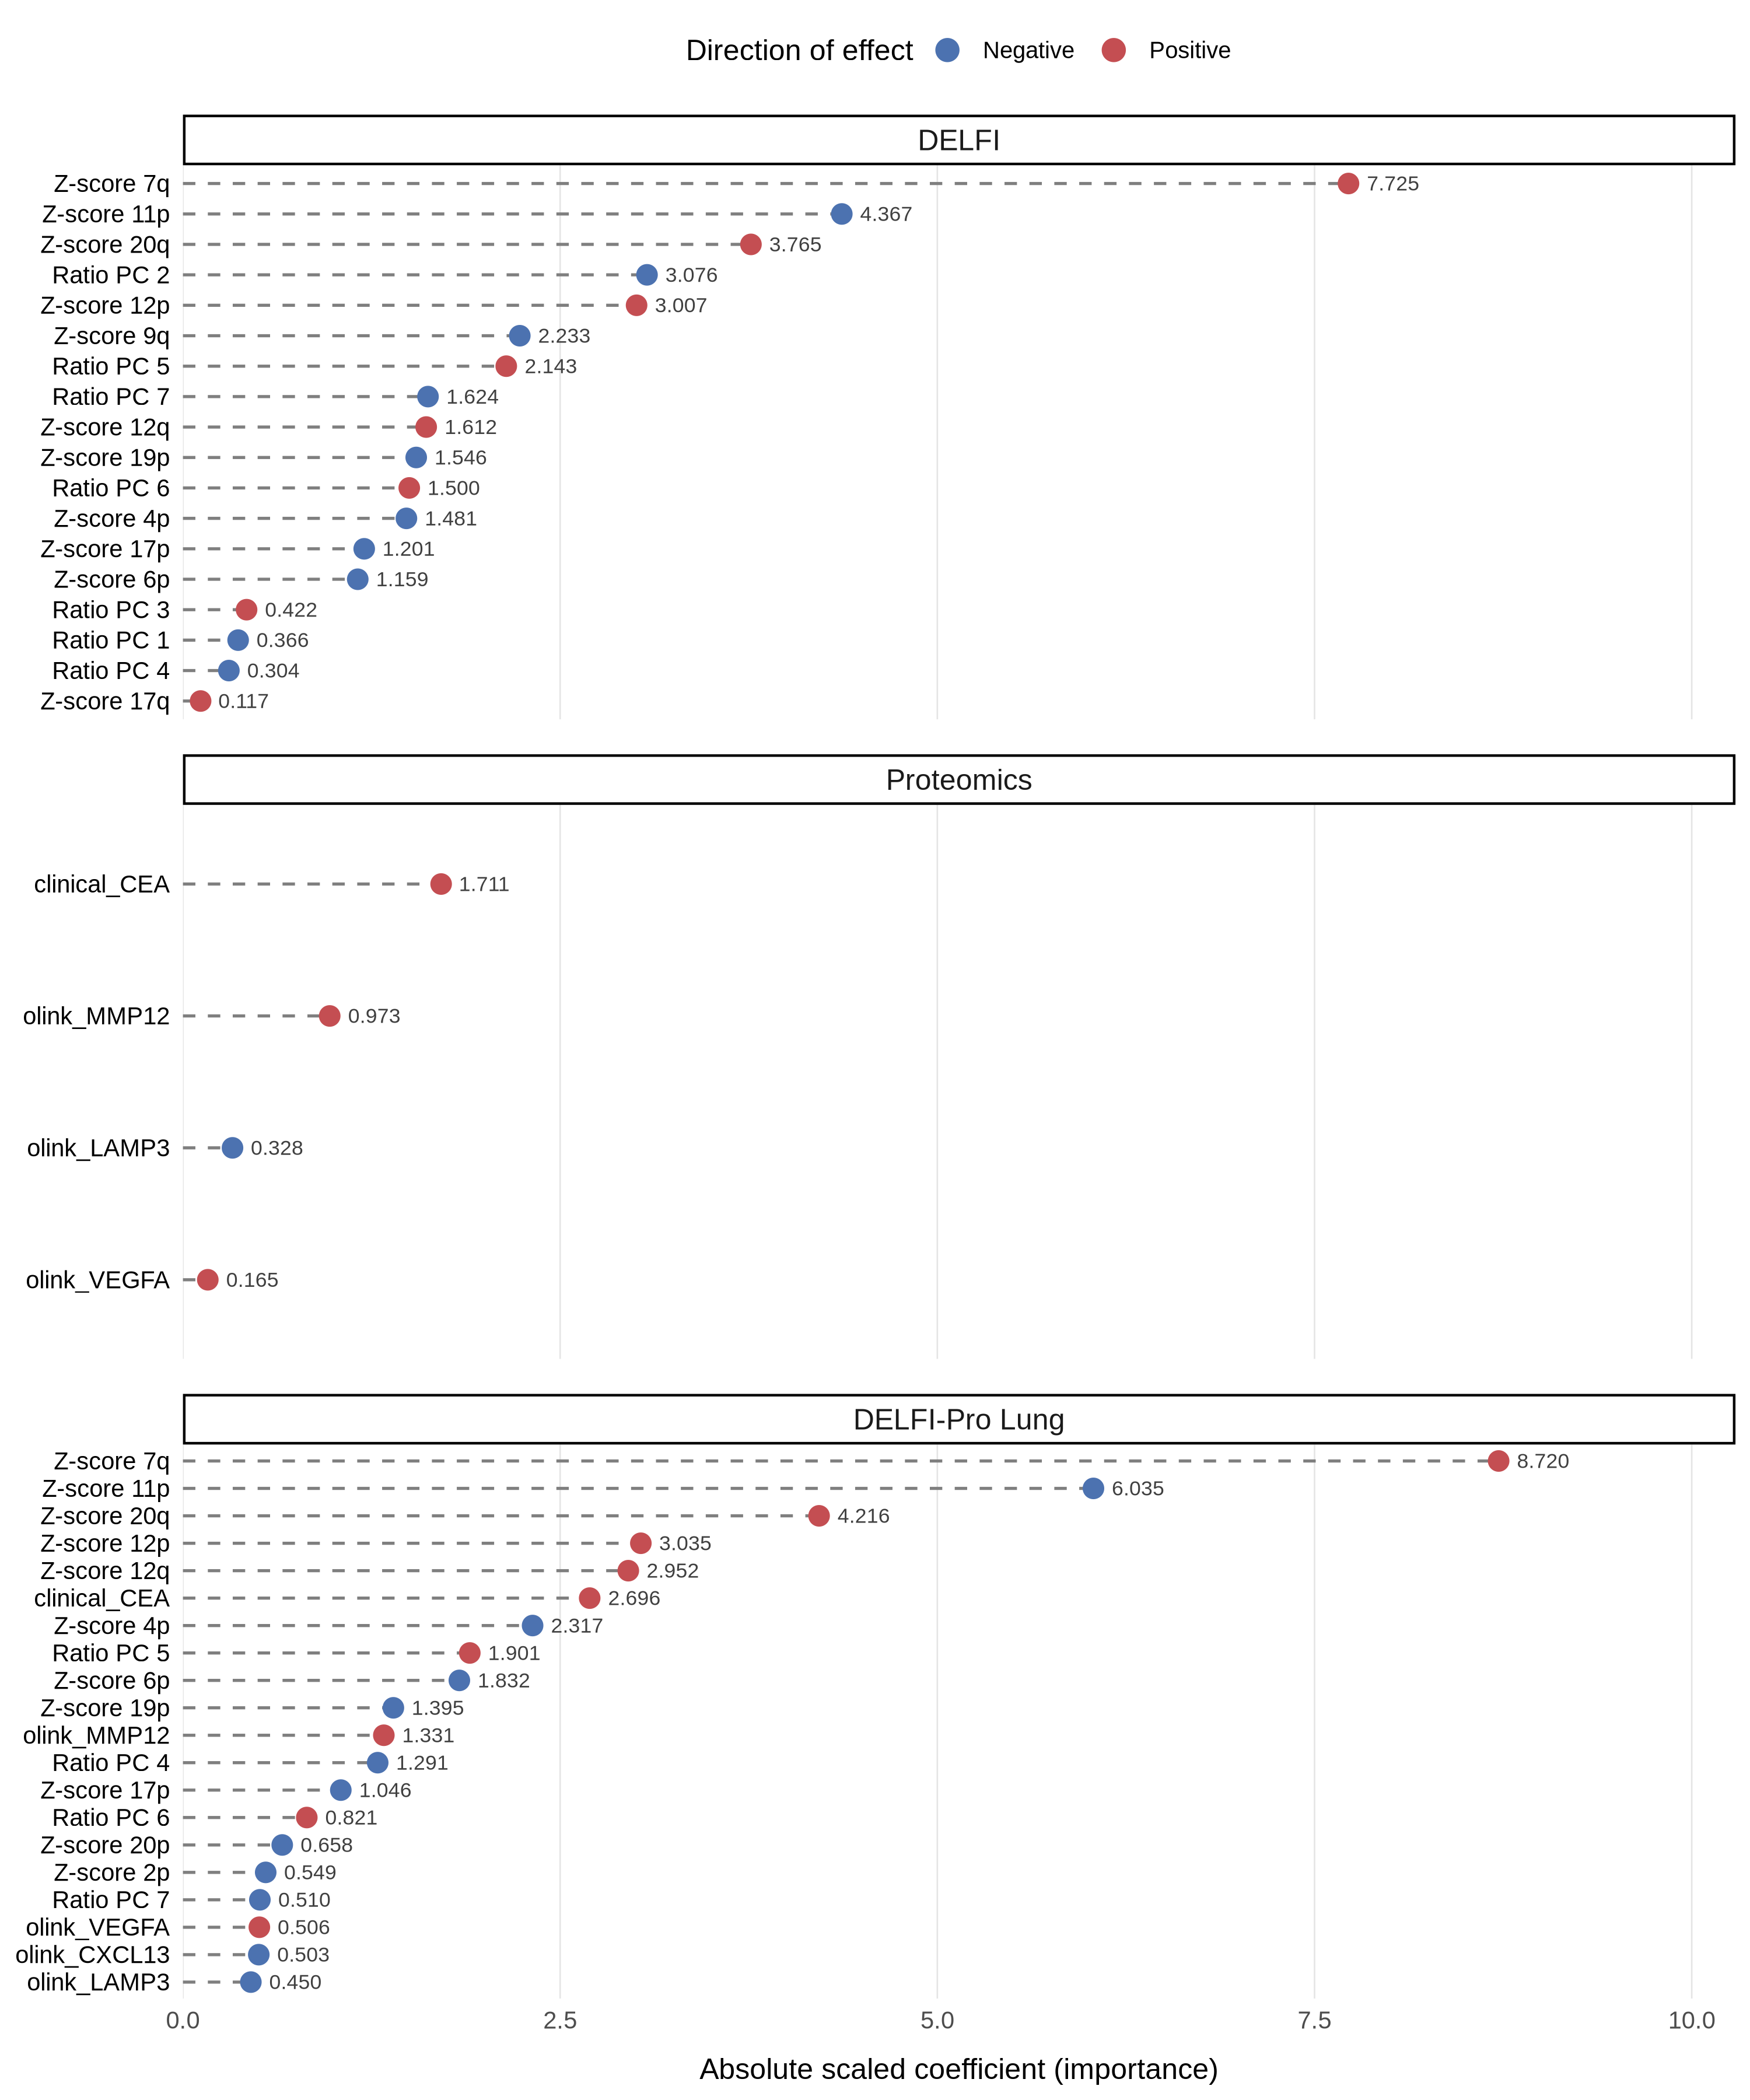

In [10]:
# Adjust paths/names to match your actual saved models
model_delfi      <- readRDS("../../models_code/FINAL/model_seq_glm.rds")
model_proteomics <- readRDS("../../models_code/FINAL/model_olink_only_FULL_glm.rds")
model_delfi_pro  <- readRDS("../../models_code/FINAL/model_seq_olink_FULL_glm.rds")

library(tidyverse)
library(patchwork)
library(recipes)

extract_scaled_coefs <- function(model, model_name, top_n = 20) {
  # Flip coefficients so positive = more cancer-like
  orig_coefs <- coef(model$finalModel, s = model$bestTune$lambda) * (-1)

  pr <- prep(model$recipe)
  traindat <- model$trainingData %>%
    mutate(id = factor(id), type = factor(type))
  model_input <- bake(pr, new_data = traindat)

  feature_sds <- model_input %>%
    dplyr::select(-c(id, type)) %>%
    as.data.frame() %>%
    summarise_all(sd)

  feature_coefs <- data.frame(
    feature = names(feature_sds),
    sd      = as.numeric(feature_sds)
  ) %>%
    merge(
      data.frame(feature    = rownames(orig_coefs),
                 orig_coefs = as.numeric(orig_coefs)),
      by = "feature", all.x = TRUE
    )

  feature_coefs$scaled_coefs <- feature_coefs$orig_coefs * feature_coefs$sd

  feature_coefs %>%
    as_tibble() %>%
    filter(!is.na(scaled_coefs), scaled_coefs != 0) %>%
    mutate(
      model      = model_name,
      importance = abs(scaled_coefs),          # <- what we now plot
      direction  = ifelse(scaled_coefs >= 0, "Positive", "Negative"),
      feature_label = case_when(
        str_detect(feature, "^ratio_pc_") ~ gsub("ratio_pc_0?", "Ratio PC ", feature),
        str_detect(feature, "^zscore_")   ~ gsub("zscore_", "Z-score ", feature),
        TRUE ~ feature
      )
    ) %>%
    arrange(desc(importance)) %>%
    slice_head(n = top_n)
}

# ============================================================

all_coefs <- bind_rows(
  extract_scaled_coefs(model_delfi,      "DELFI"),
  extract_scaled_coefs(model_proteomics, "Proteomics"),
  extract_scaled_coefs(model_delfi_pro,  "DELFI-Pro Lung")
) %>%
  mutate(model = factor(model, levels = c("DELFI", "Proteomics", "DELFI-Pro Lung")))

# ---- per-facet ordering ------------------------------------------------
# A plain reorder() builds ONE global factor level set, which misorders rows
# whenever a feature appears in more than one model. Suffix the label with the
# model to make each level unique, then strip the suffix at the axis.
all_coefs <- all_coefs %>%
  group_by(model) %>%
  arrange(desc(importance), .by_group = TRUE) %>%
  mutate(rank = row_number()) %>%
  ungroup() %>%
  mutate(
    y_key = paste(feature_label, model, sep = "___"),
    # ascending importance -> most important ends up at the TOP of the panel
    y_key = fct_reorder(y_key, importance, .desc = FALSE)
  )

strip_key <- function(x) sub("___.*$", "", x)

# ============================================================
# PLOT — absolute importance, ranked most to least informative
# ============================================================

options(repr.plot.width = 10, repr.plot.height = 12, repr.plot.res = 300)

p <- ggplot(all_coefs, aes(x = importance, y = y_key)) +
  geom_segment(
    aes(x = 0, xend = importance, yend = y_key),
    color = "grey50", linewidth = 0.6, linetype = "dashed"
  ) +
  geom_point(aes(color = direction), size = 3.5) +
  geom_text(
    aes(label = sprintf("%.3f", importance)),
    hjust = -0.35, size = 3, color = "grey25"
  ) +
  scale_color_manual(
    values = c("Positive" = "#C44E52", "Negative" = "#4C72B0"),
    name   = "Direction of effect"
  ) +
  scale_y_discrete(labels = strip_key) +
  scale_x_continuous(
    limits = c(0, NA),
    expand = expansion(mult = c(0, 0.18))
  ) +
  facet_wrap(~ model, ncol = 1, scales = "free_y") +
  labs(x = "Absolute scaled coefficient (importance)", y = NULL) +
  theme_minimal(base_size = 12) +
  theme(
    strip.background   = element_rect(color = "black", fill = "white", linewidth = 1),
    strip.text         = element_text(size = 12),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.grid.major.x = element_line(color = "grey90", linewidth = 0.3),
    panel.spacing      = unit(1, "lines"),
    axis.text.y        = element_text(size = 10, color = "black"),
    axis.text.x        = element_text(size = 10),
    axis.title.x       = element_text(size = 12, margin = margin(t = 10)),
    legend.position    = "top",
    legend.justification = "center"
  ) +
  guides(color = guide_legend(override.aes = list(size = 4)))

print(p)

ggsave(
  "../../outputs/Extended/Ext-Data-Fig-8-Model_feature_importance.png",
  plot = p,
  width = 10,
  height = 12,
  units = "in",
  dpi = 600,
  bg = "white"
)

# Extended Data Fig. 9

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


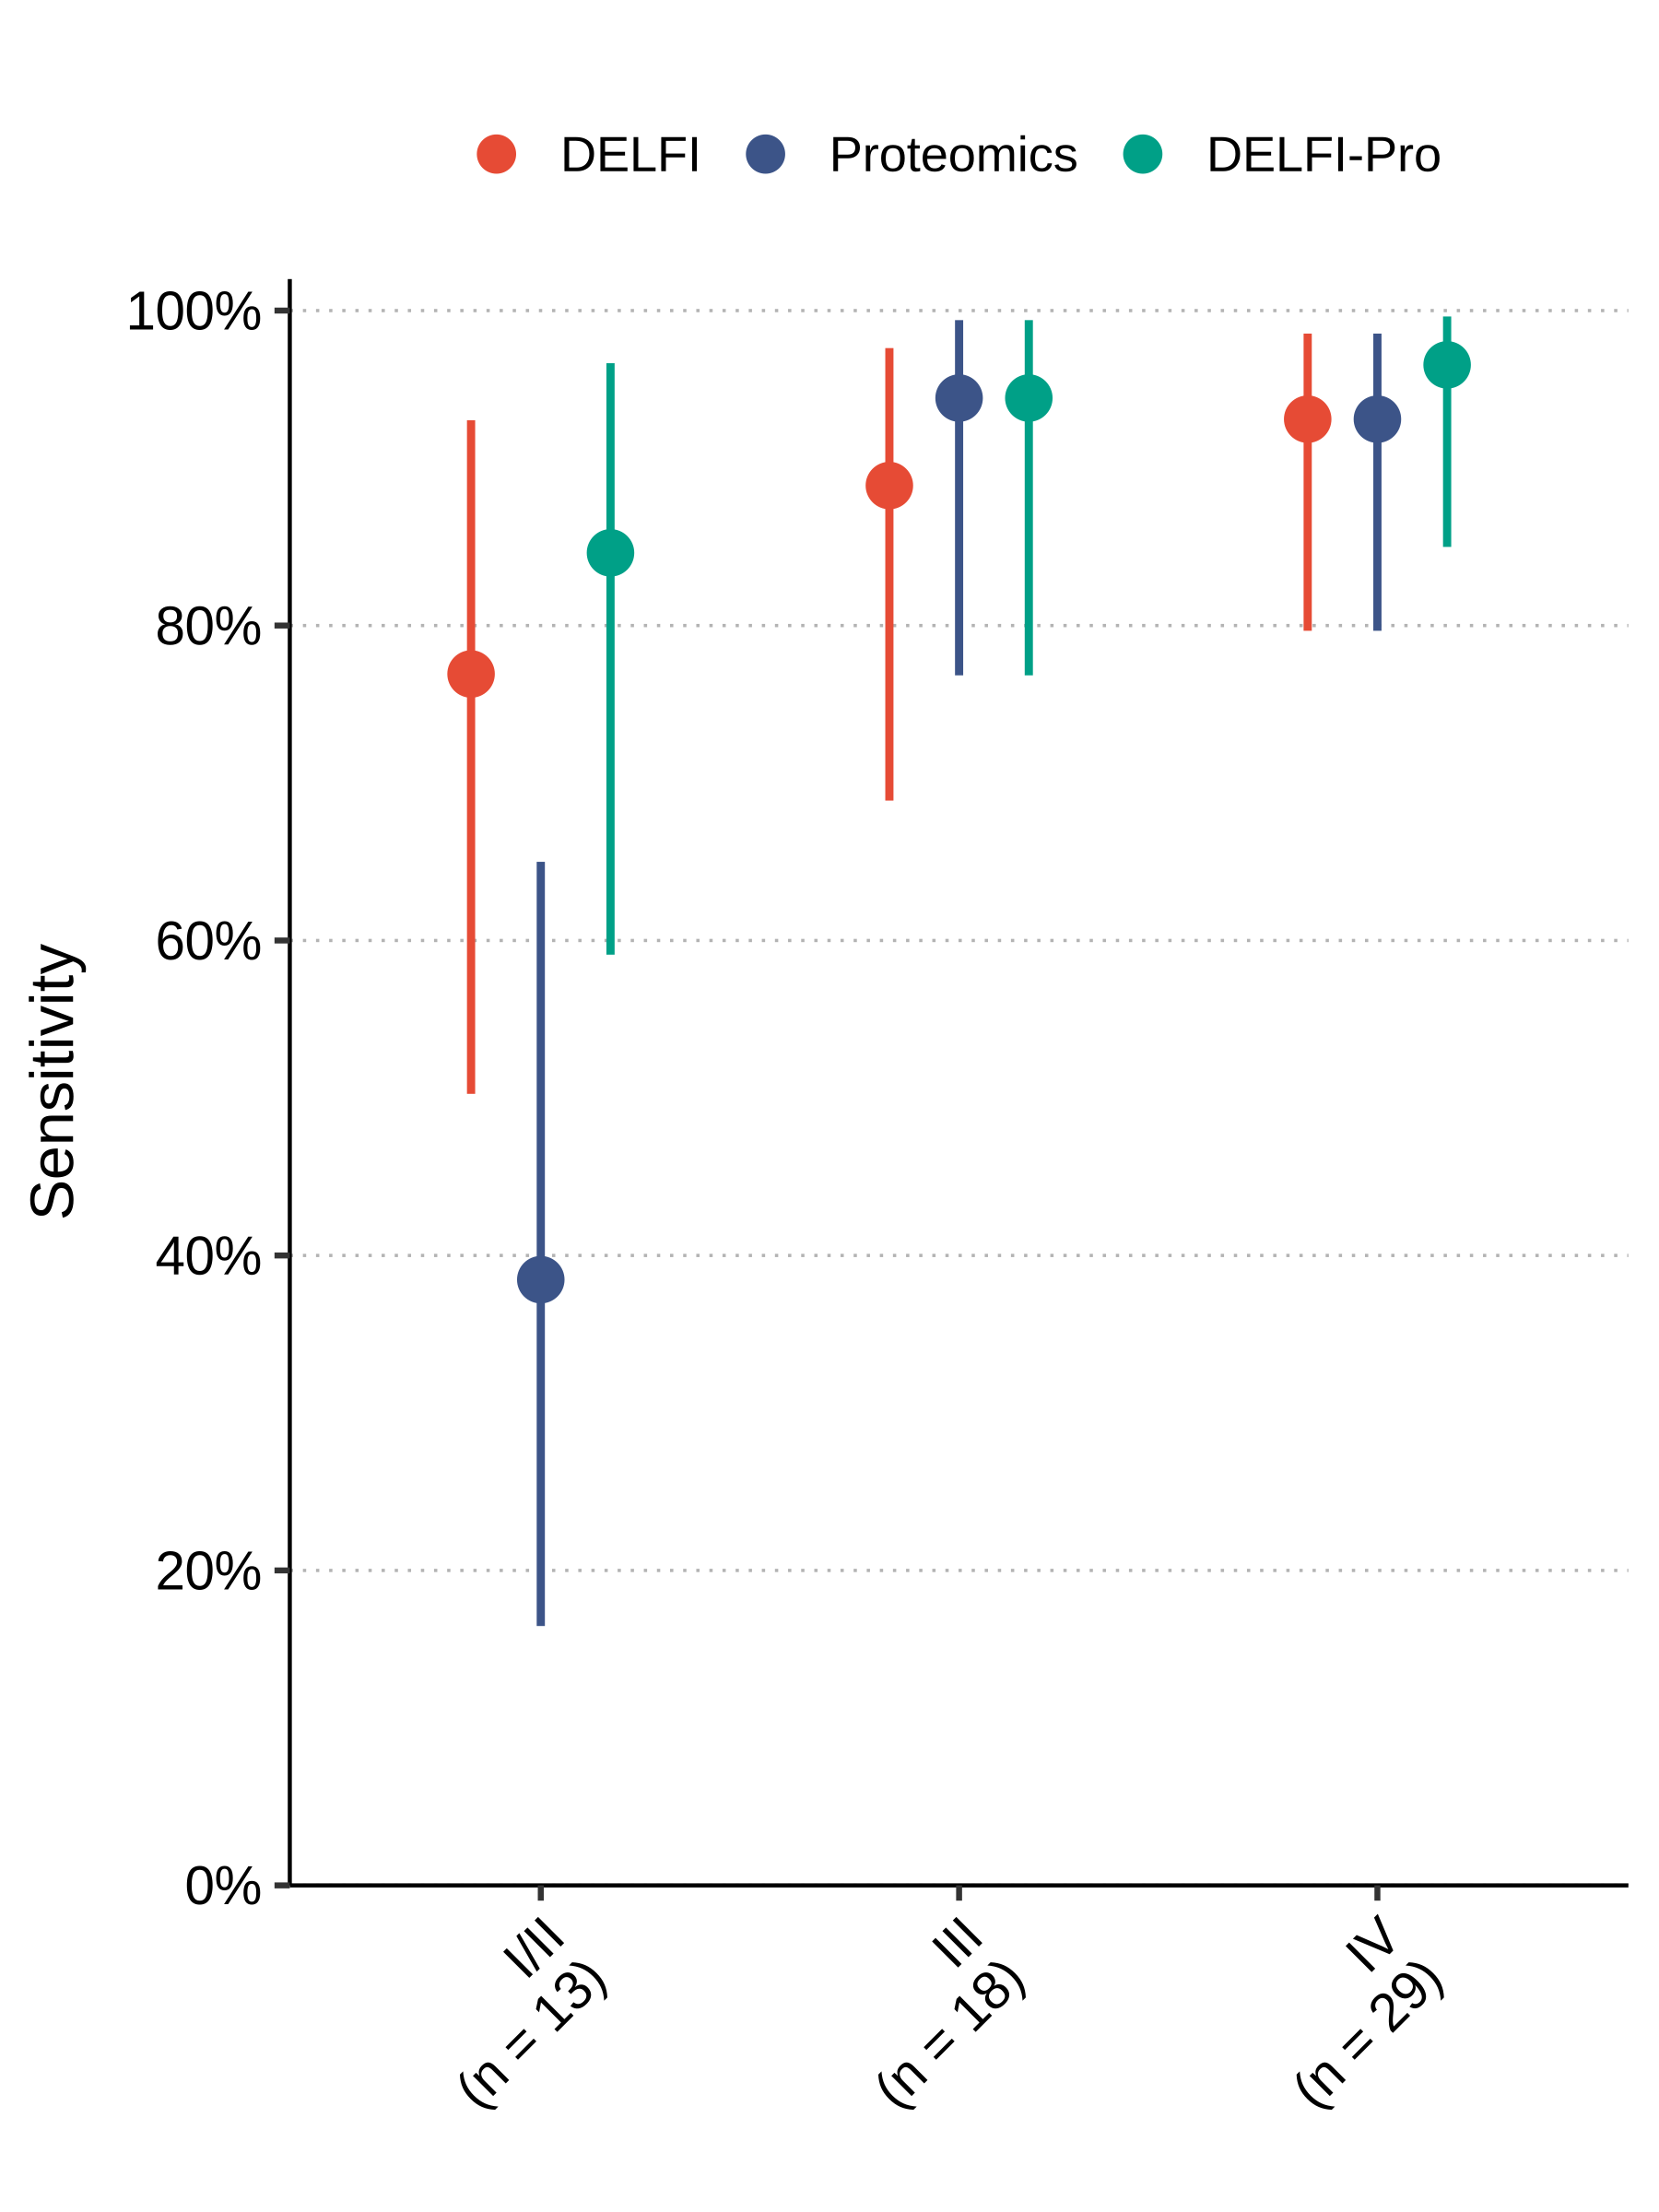

In [11]:
# Function to create LUCAS training sensitivity by stage figure
# Supports plotting one, two, or three models side by side
create_lucas_training_sensitivity_figure <- function(
    model_names = "DELFI",
    specificity_cutoff = 0.80,
    se_level = 0.95,
    plot_width = 6,
    plot_height = 8
) {
    # Accept a single string or a vector of 1-3 model names
    if (length(model_names) > 3) {
        stop("Maximum of 3 models can be plotted side by side.")
    }

    # Model mapping
    model_map <- list(
        "DELFI" = list(idx = 1, score_col = "score.seq", display_name = "DELFI", dat = dat1),
        "Proteomics" = list(idx = 2, score_col = "score.olink.only", display_name = "Proteomics", dat = dat2),
        "DELFI-Pro" = list(idx = 3, score_col = "score.seq.olink", display_name = "DELFI-Pro", dat = dat3)
    )

    # Validate models
    for (mn in model_names) {
        if (!mn %in% names(model_map)) {
            stop(paste("Invalid model name:", mn,
                       ". Valid options are:", paste(names(model_map), collapse = ", ")))
        }
    }

    # Convert SE level to quantiles
    alpha <- 1 - se_level
    lower_quantile <- alpha / 2
    upper_quantile <- 1 - alpha / 2

    # Precompute overall list for threshold calculation
    overall.list <- split(
        bind_rows(dat1, dat2, dat3) %>%
            mutate(training_model = factor(training_model, model_levels)) %>%
            left_join(clindat, by = "lab_id") %>%
            mutate(class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
                   class = factor(class, c("No cancer", "Cancer"))),
        ~ training_model
    )

    # ---- Color palettes for each model slot ----
    # Each model gets ONE solid, distinct, easy-to-tell-apart color
    # (same color used for all three stages within that model)
    palette_1 <- c(
        "I/II" = "#E64B35",   # DELFI - red/vermillion
        "III"  = "#E64B35",
        "IV"   = "#E64B35"
    )
    palette_2 <- c(
        "I/II" = "#3C5488",   # Proteomics - deep blue
        "III"  = "#3C5488",
        "IV"   = "#3C5488"
    )
    palette_3 <- c(
        "I/II" = "#00A087",   # DELFI-Pro - teal/green
        "III"  = "#00A087",
        "IV"   = "#00A087"
    )

    palette_list <- list(palette_1, palette_2, palette_3)

    # ---- Compute stage performance for each model ----
    all_stage_perf <- lapply(seq_along(model_names), function(i) {
        mn <- model_names[i]
        model_info <- model_map[[mn]]

        # Calculate threshold at specified specificity cutoff
        lucas_roc <- overall.list[[model_info$idx]] %>% select(score, class)
        tmp <- pROC::roc(class ~ score, data = lucas_roc, ret = TRUE, quiet = TRUE)
        cutoff_threshold <- tibble(sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds) %>%
            filter(spec >= specificity_cutoff) %>%
            arrange(spec) %>%
            slice(1) %>%
            pull(thresholds)

        # Prepare LUCAS data
        lucas_data <- left_join(model_info$dat, clindat, by = "lab_id") %>%
            select(lab_id, score, stage, patient_type) %>%
            mutate(
                class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
                class = factor(class, c("No cancer", "Cancer"))
            )

        # Combine stages I and II into "I/II"
        lucas_cancer <- filter(lucas_data, class == "Cancer", !is.na(stage)) %>%
            filter(stage %in% c("I", "II", "III", "IV")) %>%
            mutate(
                stage_combined = case_when(
                    stage %in% c("I", "II") ~ "I/II",
                    TRUE ~ as.character(stage)
                )
            )

        # Calculate performance
        stage_perf <- lucas_cancer %>%
            group_by(stage_combined) %>%
            summarise(
                n = n(),
                tp = sum(score >= cutoff_threshold),
                sens = tp / n,
                .groups = "drop"
            ) %>%
            mutate(
                sens_lower = qbeta(lower_quantile, 0.5 + tp, 0.5 + (n - tp)),
                sens_upper = qbeta(upper_quantile, 0.5 + tp, 0.5 + (n - tp))
            ) %>%
            mutate(stage_combined = factor(stage_combined, levels = c("I/II", "III", "IV"))) %>%
            arrange(stage_combined) %>%
            mutate(
                model = mn,
                model_idx = i
            )

        stage_perf
    }) %>% bind_rows()

    # Create stage labels with sample sizes (from first model — same cohort)
    stage_labels_df <- all_stage_perf %>%
        filter(model_idx == 1) %>%
        mutate(stage_label = paste0(stage_combined, "\n(n = ", n, ")"))

    stage_label_vec <- setNames(stage_labels_df$stage_label, stage_labels_df$stage_combined)

    # ---- Build color and fill mappings ----
    multi_mode <- length(model_names) > 1

    if (multi_mode) {
        # Interaction key for per-dot coloring
        all_stage_perf <- all_stage_perf %>%
            mutate(model_stage = paste0(model, ":", stage_combined),
                   model = factor(model, levels = model_names))

        # Build color map from all model slots in use
        color_map <- unlist(lapply(seq_along(model_names), function(i) {
            setNames(palette_list[[i]], paste0(model_names[i], ":", names(palette_list[[i]])))
        }))
    } else {
        all_stage_perf <- all_stage_perf %>%
            mutate(model_stage = as.character(stage_combined),
                   model = factor(model, levels = model_names))

        color_map <- palette_1
    }

    # ---- Create the plot ----
    options(repr.plot.width = plot_width, repr.plot.height = plot_height,
            message = FALSE, warning = FALSE)

    dodge_width <- if (multi_mode) 0.5 else 0
    pd <- position_dodge(width = dodge_width)

    p <- all_stage_perf %>%
        ggplot(aes(x = stage_combined, y = sens, color = model_stage, fill = model_stage,
                   group = model)) +
        # Colored error bars with NO hats (geom_linerange)
        geom_linerange(aes(ymin = sens_lower, ymax = sens_upper),
                       size = 1, position = pd) +
        # Larger dots, colored fill + colored border
        geom_point(size = 5, shape = 21, stroke = 0.6, position = pd) +
        scale_y_continuous(
            name = "Sensitivity",
            limits = c(0, 1),
            breaks = seq(0, 1, 0.2),
            labels = scales::percent_format(accuracy = 1),
            expand = expansion(add = c(0, 0.02))
        ) +
        scale_x_discrete(
            name = "",
            labels = stage_label_vec
        ) +
        scale_fill_manual(values = color_map, guide = "none") +
        scale_color_manual(values = color_map, guide = "none") +
        theme_classic(base_size = 16) +
        theme(
            # Horizontal dotted gridlines
            panel.grid.major.y = element_line(color = "gray70", linetype = "dotted", size = 0.4),
            panel.grid.minor = element_blank(),
            panel.grid.major.x = element_blank(),
            axis.line = element_line(color = "black", size = 0.5),
            axis.text.x = element_text(angle = 45, hjust = 1, color = "black", size = 14),
            axis.text.y = element_text(color = "black", size = 14),
            axis.title.y = element_text(color = "black", size = 16, margin = margin(r = 10)),
            axis.title.x = element_blank(),
            plot.background = element_rect(fill = "white", color = NA),
            panel.background = element_rect(fill = "white", color = NA),
            aspect.ratio = 1.2
        )

    # Add legend in multi-model mode
    if (multi_mode) {
        # Representative color per model (single solid color now, so any stage works)
        legend_colors <- setNames(
            sapply(seq_along(model_names), function(i) palette_list[[i]]["III"]),
            model_names
        )

        shape_values <- setNames(rep(21, length(model_names)), model_names)

        p <- p +
            geom_point(aes(shape = model), size = 0, alpha = 0) +
            scale_shape_manual(values = shape_values, name = NULL) +
            guides(shape = guide_legend(
                override.aes = list(
                    size = 4,
                    alpha = 1,
                    fill = unname(legend_colors),
                    color = unname(legend_colors),
                    stroke = 0.6
                )
            )) +
            theme(
                legend.position = "top",
                legend.text = element_text(size = 13),
                legend.key = element_rect(fill = "white", color = NA),
                legend.background = element_rect(fill = "white", color = NA)
            )
    }

    return(p)
}

# =====================================================================
# USAGE EXAMPLES
# =====================================================================

options(repr.plot.width = 6, repr.plot.height = 24)

# --- All three models side by side ---
C <- create_lucas_training_sensitivity_figure(
    model_names = c("DELFI", "Proteomics", "DELFI-Pro"),
    specificity_cutoff = 0.60,
    se_level = 0.95
)
C

In [12]:
ggsave("../../outputs/Extended/Ext-Data-Fig-9-Model-LUCAS_training_three_models_sensitivity_60spec.png",
       plot = C, width = 6, height = 12, units = "in", dpi = 300)

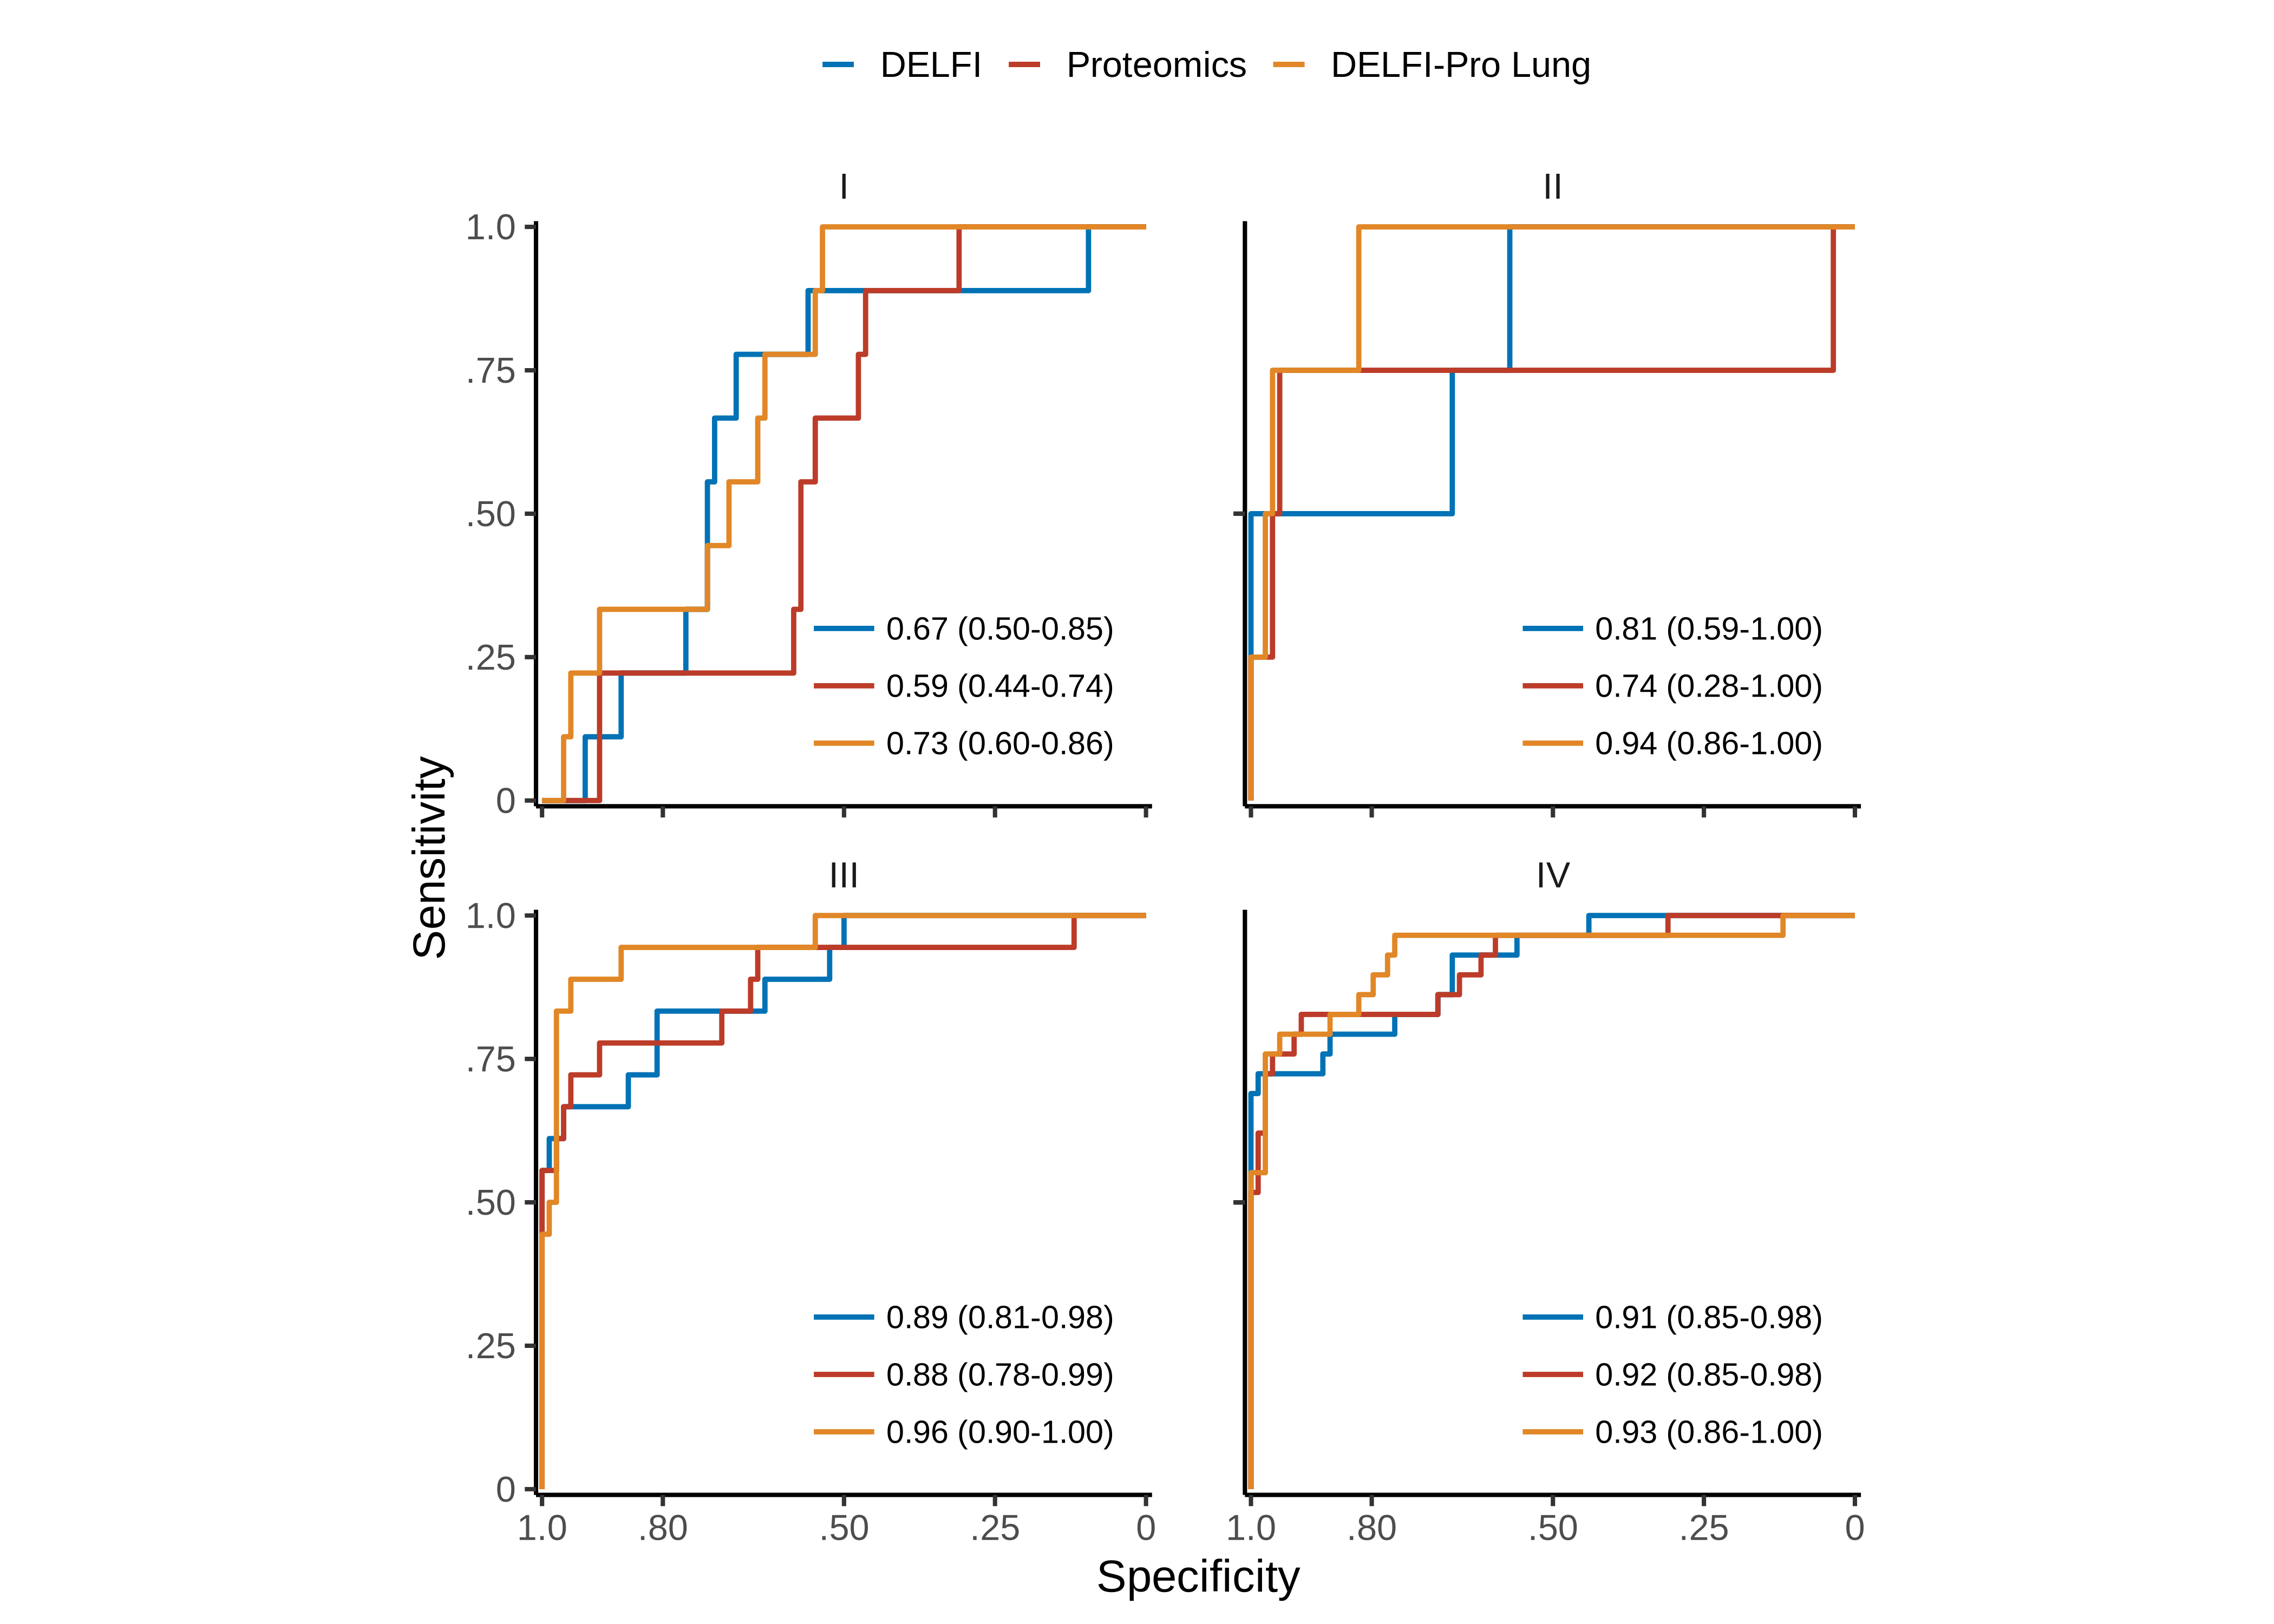

In [12]:
## Figure C2: ROC Curves by Stage
options(repr.plot.width = 14, repr.plot.height = 10, message = FALSE, warning = FALSE)
suppressMessages(suppressWarnings({
    # Compute stratified ROC data
    roc_strata <- fig3_roc(se, dat1, dat2, dat3, model_levels)

    # Remove unwanted categories — keep only Stage I-IV
    roc_strata_filtered <- roc_strata %>%
        filter(!category %in% c("Adenocarcinoma", "Squamous", "SCLC"))

    # Generate NEJM colors — same swap logic as B
    nejm_colors <- setNames(pal_nejm()(length(unique(roc_strata_filtered$training_model))),
                            unique(roc_strata_filtered$training_model))
    nejm_colors[c(1, 2)] <- nejm_colors[c(2, 1)]

    # Prepare the filtered dataset — same formatting as B
    roc_strata2 <- roc_strata_filtered %>%
        mutate(training_model = as.character(training_model),
               auc = format(round(auc, 2), nsmall = 2),
               lower = format(round(lower, 2), nsmall = 2),
               upper = format(round(upper, 2), nsmall = 2),
               auc_label = paste0(auc, " (", lower, "-", upper, ")"),
               auc_label = factor(auc_label, unique(auc_label)))

    models <- model_levels

    legends <- roc_strata2 %>%
        select(category, training_model, auc_label) %>%
        distinct() %>%
        mutate(training_model = factor(training_model, unique(training_model)),
               training_model = fct_rev(training_model),
               x = 0.45,
               xend = 0.55,
               y = c(0.1, 0.2, 0.3)[as.integer(training_model)])

    C2 <- roc_strata2 %>%
        mutate(training_model = factor(training_model, models)) %>%
        ggplot(aes(spec, sens, group = training_model))

    if (SHOW_SPECIFICITY_LINE) {
        C2 <- C2 + geom_vline(xintercept = 0.80, color = "gray80", size = 0.5, linetype = "dashed")
    }

    C2 <- C2 +
        geom_line(aes(color = training_model), size = 1.1) +
        scale_x_reverse(expand = c(0, 0.01),
                        breaks = c(0, 0.25, 0.5, 0.80, 1),
                        labels = as.character(c("0", ".25", ".50", ".80", "1.0"))) +
        scale_y_continuous(expand = c(0, 0.01),
                           breaks = c(0, 0.25, 0.5, 0.75, 1),
                           labels = as.character(c("0", ".25", ".50", ".75", "1.0"))) +
        geom_segment(data = legends, aes(x = x, xend = xend,
                                         y = y, yend = y,
                                         color = training_model),
                     size = 1.1,
                     inherit.aes = FALSE) +
        geom_text(data = legends, aes(x = xend, y = y, label = auc_label),
                  nudge_x = 0.12, hjust = 0,
                  size = 5) +
        scale_color_manual(values = nejm_colors) +
        theme_classic(base_size = 20) +
        theme(panel.background = element_blank(),
              panel.grid = element_blank(),
              legend.position = "top",
              axis.line.x.bottom = element_line(color = "black"),
              strip.background = element_blank(),
              aspect.ratio = 0.95,
              legend.title = element_text(size = 16)) +
        xlab("Specificity") + ylab("Sensitivity") +
        guides(color = guide_legend(title = "")) +
        facet_rep_wrap(~category, nrow = 2)
}))
C2

ggsave("../../outputs/Extended/Ext-Data-Fig-9_stage_train_CV_FULL_roc.png",
       plot = C2, width = 16, height = 10, dpi = 600)

In [13]:
lucas_clinical <- read_csv("../../data/Cross-React_all_cohorts_combinedV2.csv")
lucas_df <- read_csv("../../data/lucas_df_with_pcs.csv")

build_lucas_scores_pooled <- function(
  model_name = "DELFI-Pro",
  combined_val,
  dat1, dat2, dat3,
  clindat,
  nocancer_labels,
  id_map = NULL  
) {

  model_map <- list(
    "DELFI"      = list(dat = dat1, score_col_train = "score", score_col_test = "score.seq"),
    "Proteomics" = list(dat = dat2, score_col_train = "score", score_col_test = "score.olink"),
    "DELFI-Pro"  = list(dat = dat3, score_col_train = "score", score_col_test = "score.seq.olink")
  )
  mi <- model_map[[model_name]]
  if (is.null(mi)) stop("model_name must be one of: DELFI, Proteomics, DELFI-Pro")

  # --- LUCAS TRAINING scores (needs id) ---
  train0 <- mi$dat %>%
    dplyr::left_join(clindat, by = "lab_id") %>%
    dplyr::mutate(
      class = ifelse(.data$patient_type %in% nocancer_labels, "No cancer", "Cancer"),
      class = factor(.data$class, levels = c("No cancer", "Cancer"))
    )

  # pick id column:
  # prefer train0$id if present, else try clindat$id, else require id_map
  if (!("id" %in% names(train0))) {
    if (!is.null(id_map) && all(c("lab_id","id") %in% names(id_map))) {
      train0 <- train0 %>% dplyr::left_join(id_map, by = "lab_id")
    } else {
      stop("Training data does not contain 'id'. Provide id_map with columns lab_id,id (or ensure clindat has id).")
    }
  }

  train_scores <- train0 %>%
    dplyr::transmute(
      id = .data$id,
      score = .data[[mi$score_col_train]],
      class = .data$class
    )

  # --- LUCAS TEST scores (from combined_val) ---
  test_scores <- combined_val %>%
    dplyr::filter(.data$cohort == "LUCAS") %>%
    dplyr::transmute(
      id = .data$id,
      score = .data[[mi$score_col_test]],
      class = factor(.data$class, levels = c("No cancer", "Cancer"))
    )

  # --- pooled ---
  dplyr::bind_rows(
    train_scores %>% dplyr::mutate(dataset = "Training (LUCAS)"),
    test_scores  %>% dplyr::mutate(dataset = "Test (LUCAS)")
  ) %>% dplyr::distinct(.data$id, .keep_all = TRUE)
}

lucas_scores_pooled <- build_lucas_scores_pooled(
  model_name = "DELFI-Pro",
  combined_val = combined_val,
  dat1 = dat1, dat2 = dat2, dat3 = dat3,
  clindat = clindat,
  nocancer_labels = nocancer_labels,
  id_map = meta %>% dplyr::select(lab_id, id) %>% dplyr::distinct()
)

Rows: 1041 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): id, type, group, Cancer, cohort

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 287 Columns: 958
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (96): Patient, id, type, clinical_smokingstatus, QC, patient.type, cli...
dbl  (850): multinucratio, clinical_nlratio, clinical_CRP, clinical_cfdna_co...
lgl    (3): DIAGNOSE_OTHER_PRIMARY, Adaptor Dimer, Date Data Received
date   (9): DATE_1_VISIT_BBH, DATE_BIOPSY, DATE_SCAN_BASELINE, DATE_FEV1, DA...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [14]:
# Load lucas_df for diabetes info
#lucas_df <- read_csv("../../data/lucas_df_with_pcs.csv", show_col_types = FALSE)

create_lucas_clinical_subgroup_figure <- function(
  scores_df,
  meta,
  lucas_df,
  specificity_cutoff = 0.60,
  locked_threshold = NULL,        
  se_level = 0.95,               
  age_cutoff = 65,
  bmi_cutoff = 25,
  packyears_cutoff = 30,
  show_comorbidity_complements = TRUE,
  plot_width = 7,
  plot_height = 11
) {

  # ---- checks ----
  if (!all(c("id", "score", "class") %in% names(scores_df))) {
    stop("scores_df must contain: id, score, class")
  }
  if (!("id" %in% names(meta))) stop("meta must contain id")

  # ---- Wilson score CI ----                                   
  wilson_ci <- function(x, n) {
    if (is.na(n) || n == 0) return(tibble::tibble(lower = NA_real_, upper = NA_real_))
    ci <- suppressWarnings(
      stats::prop.test(x, n, conf.level = se_level, correct = FALSE)$conf.int
    )
    tibble::tibble(lower = ci[1], upper = ci[2])
  }

  # ---- standardize class ----
  df0 <- scores_df %>%
    dplyr::mutate(
      class = dplyr::case_when(
        .data$class %in% c("Cancer", "cancer") ~ "Cancer",
        .data$class %in% c("No cancer", "No Cancer", "nocancer", "no cancer") ~ "No cancer",
        TRUE ~ as.character(.data$class)
      ),
      class = factor(.data$class, levels = c("No cancer", "Cancer"))
    )

  if (any(is.na(df0$class))) {
    warning(sum(is.na(df0$class)), " row(s) had an unrecognized class label and were dropped.")
    df0 <- df0 %>% dplyr::filter(!is.na(.data$class))
  }

  # ---- join meta ----
  df <- df0 %>%
    dplyr::left_join(
      meta %>%
        dplyr::select(id, Smoking_status, age, Sex, Packyears, bmi, COPD),
      by = "id"
    ) %>%
    dplyr::mutate(
      smoking_bin = dplyr::case_when(
        is.na(.data$Smoking_status) ~ NA_character_,
        tolower(.data$Smoking_status) %in% c("smoker", "current", "current smoker") ~ "Current",
        tolower(.data$Smoking_status) %in% c("former", "former smoker", "ex-smoker", "ex smoker") ~ "Former",
        TRUE ~ NA_character_
      ),
      smoking_bin = factor(.data$smoking_bin, levels = c("Current", "Former")),
      sex_bin = dplyr::case_when(
        is.na(.data$Sex) ~ NA_character_,
        .data$Sex %in% c("Male", "male", "M") ~ "Male",
        .data$Sex %in% c("Female", "female", "F") ~ "Female",
        TRUE ~ NA_character_
      ),
      sex_bin = factor(.data$sex_bin, levels = c("Male", "Female"))
    )

  unmapped_smk <- df %>%
    dplyr::filter(!is.na(.data$Smoking_status), is.na(.data$smoking_bin)) %>%
    dplyr::pull(.data$Smoking_status) %>% unique()
  if (length(unmapped_smk)) {
    warning("Unmapped Smoking_status value(s), excluded from the smoking rows: ",
            paste(unmapped_smk, collapse = ", "))
  }
  unmapped_sex <- df %>%
    dplyr::filter(!is.na(.data$Sex), is.na(.data$sex_bin)) %>%
    dplyr::pull(.data$Sex) %>% unique()
  if (length(unmapped_sex)) {
    warning("Unmapped Sex value(s), excluded from the sex rows: ",
            paste(unmapped_sex, collapse = ", "))
  }

  diabetes_ids <- lucas_df %>%
    dplyr::filter(clinical_chronic_inflammatory_conditions == "DM 2") %>%
    dplyr::pull(id)

  df <- df %>%
    dplyr::mutate(has_diabetes = .data$id %in% diabetes_ids)


  thr <- if (!is.null(locked_threshold)) {
    locked_threshold
  } else {
    warning("No locked_threshold supplied; deriving the threshold from scores_df. ",
            "This is circular if scores_df is not the training set.")
    roc_obj <- pROC::roc(class ~ score, data = df, quiet = TRUE)
    cutoff_row <- tibble::tibble(
      sens = roc_obj$sens, spec = roc_obj$spec, thresholds = roc_obj$thresholds
    ) %>%
      dplyr::filter(.data$spec >= specificity_cutoff) %>%
      dplyr::arrange(.data$spec) %>%
      dplyr::slice(1)
    if (nrow(cutoff_row) == 0) stop("No threshold achieves specificity_cutoff; lower it.")
    cutoff_row$thresholds[[1]]
  }

  overall_sens <- {
    s <- df %>% dplyr::filter(.data$class == "Cancer") %>% dplyr::pull(.data$score)
    s <- s[!is.na(s)]
    if (length(s) == 0) NA_real_ else mean(s >= thr)
  }
  overall_spec <- {
    s <- df %>% dplyr::filter(.data$class == "No cancer") %>% dplyr::pull(.data$score)
    s <- s[!is.na(s)]
    if (length(s) == 0) NA_real_ else mean(s < thr)
  }

  # ---- compute sens/spec for a subgroup ----------------------------------
  compute_pair <- function(dsub, label, section) {
    s_c <- dsub %>% dplyr::filter(.data$class == "Cancer") %>% dplyr::pull(.data$score)
    s_c <- s_c[!is.na(s_c)]
    n_c <- length(s_c); tp <- sum(s_c >= thr)
    sens <- if (n_c == 0) NA_real_ else tp / n_c
    ci_s <- wilson_ci(tp, n_c)

    s_n <- dsub %>% dplyr::filter(.data$class == "No cancer") %>% dplyr::pull(.data$score)
    s_n <- s_n[!is.na(s_n)]
    n_n <- length(s_n); tn <- sum(s_n < thr)
    spec <- if (n_n == 0) NA_real_ else tn / n_n
    ci_p <- wilson_ci(tn, n_n)

    tibble::tibble(
      section  = section,
      subgroup = paste0(label, " (n = ", n_c + n_n, ")"),
      metric   = c("Sensitivity", "Specificity"),
      value    = c(sens, spec),
      lower    = c(ci_s$lower, ci_p$lower),
      upper    = c(ci_s$upper, ci_p$upper),
      n_metric = c(n_c, n_n)
    )
  }

  out <- list()

  # Overall
  out[["overall"]] <- compute_pair(df, "Overall", "All")

  # Age
  out[["age_lt"]] <- compute_pair(df %>% dplyr::filter(!is.na(.data$age), .data$age < age_cutoff),
                                  paste0("Age < ", age_cutoff, " years"), "Age")
  out[["age_ge"]] <- compute_pair(df %>% dplyr::filter(!is.na(.data$age), .data$age >= age_cutoff),
                                  paste0("Age \u2265 ", age_cutoff, " years"), "Age")

  # Sex
  out[["sex_m"]] <- compute_pair(df %>% dplyr::filter(.data$sex_bin == "Male"), "Male", "Sex")
  out[["sex_f"]] <- compute_pair(df %>% dplyr::filter(.data$sex_bin == "Female"), "Female", "Sex")

  # Co-morbidities — NEW: complement arms so each has a comparator
  out[["cmb_copd"]] <- compute_pair(
    df %>% dplyr::filter(!is.na(.data$COPD), .data$COPD == 1), "COPD", "Co-morbidities")
  if (show_comorbidity_complements) {
    out[["cmb_nocopd"]] <- compute_pair(
      df %>% dplyr::filter(!is.na(.data$COPD), .data$COPD != 1), "No COPD", "Co-morbidities")
  }

  out[["cmb_diabetes"]] <- compute_pair(
    df %>% dplyr::filter(.data$has_diabetes), "Type-II diabetes", "Co-morbidities")
  if (show_comorbidity_complements) {
    out[["cmb_nodiabetes"]] <- compute_pair(
      df %>% dplyr::filter(!.data$has_diabetes), "No Type-II diabetes", "Co-morbidities")
  }

  out[["bmi_hi"]] <- compute_pair(
    df %>% dplyr::filter(!is.na(.data$bmi), .data$bmi > bmi_cutoff),
    paste0("BMI > ", bmi_cutoff), "Co-morbidities")
  if (show_comorbidity_complements) {
    out[["bmi_lo"]] <- compute_pair(
      df %>% dplyr::filter(!is.na(.data$bmi), .data$bmi <= bmi_cutoff),
      paste0("BMI \u2264 ", bmi_cutoff), "Co-morbidities")
  }

  # Smoking
  out[["smk_cur"]] <- compute_pair(df %>% dplyr::filter(.data$smoking_bin == "Current"),
                                   "Current", "Smoking status")
  out[["smk_not"]] <- compute_pair(df %>% dplyr::filter(.data$smoking_bin == "Former"),
                                   "Former", "Smoking status")

  # Pack-years
  out[["py_lt"]] <- compute_pair(
    df %>% dplyr::filter(!is.na(.data$Packyears), .data$Packyears < packyears_cutoff),
    paste0("<", packyears_cutoff, " pack-years"), "Pack-years")
  out[["py_ge"]] <- compute_pair(
    df %>% dplyr::filter(!is.na(.data$Packyears), .data$Packyears >= packyears_cutoff),
    paste0("\u2265", packyears_cutoff, " pack-years"), "Pack-years")

  perf <- dplyr::bind_rows(out) %>%
    dplyr::filter(!is.na(.data$value)) %>%
    dplyr::mutate(
      metric = factor(.data$metric, levels = c("Sensitivity", "Specificity")),
      section = factor(
        .data$section,
        levels = c("All", "Age", "Sex", "Co-morbidities", "Smoking status", "Pack-years")
      )
    )

  subgroup_levels <- perf %>%
    dplyr::distinct(.data$section, .data$subgroup) %>%
    dplyr::mutate(ord = dplyr::row_number()) %>%
    dplyr::arrange(.data$ord) %>%
    dplyr::pull(.data$subgroup)

  perf <- perf %>%
    dplyr::mutate(subgroup = factor(.data$subgroup, levels = rev(unique(subgroup_levels))))

  vref <- tibble::tibble(
    metric = factor(c("Sensitivity", "Specificity"), levels = c("Sensitivity", "Specificity")),
    x = c(overall_sens, overall_spec)
  )

  col_map <- c("Sensitivity" = "#d95f02", "Specificity" = "#1f77b4")

  options(repr.plot.width = plot_width, repr.plot.height = plot_height)

  p <- ggplot2::ggplot(perf, ggplot2::aes(y = subgroup, x = value)) +
    ggplot2::geom_vline(xintercept = seq(0, 1, 0.2),
                        linetype = "dashed", color = "gray55", linewidth = 0.6) +
    ggplot2::geom_vline(data = vref,
                        ggplot2::aes(xintercept = x, color = metric),
                        linewidth = 1.3) +
    ggplot2::geom_errorbarh(ggplot2::aes(xmin = lower, xmax = upper, color = metric),
                            height = 0, linewidth = 1.0) +
    ggplot2::geom_point(ggplot2::aes(color = metric), size = 2.7) +
    ggplot2::facet_grid(
      rows = ggplot2::vars(section),
      cols = ggplot2::vars(metric),
      scales = "free_y", space = "free_y", switch = "y"
    ) +
    ggplot2::scale_x_continuous(limits = c(0, 1.05), breaks = seq(0, 1, 0.2)) +
    ggplot2::scale_color_manual(values = col_map) +
    ggplot2::labs(x = NULL, y = NULL) +
    ggplot2::theme_classic(base_size = 14) +
    ggplot2::theme(
      legend.position = "none",
      panel.border = ggplot2::element_rect(color = "gray30", fill = NA, linewidth = 1.0),
      strip.background = ggplot2::element_blank(),
      strip.placement = "outside",
      strip.text.x = ggplot2::element_text(size = 14),
      strip.text.y.left  = ggplot2::element_text(size = 12, angle = 0),
      strip.text.y.right = ggplot2::element_text(size = 12, angle = 270),
      axis.text.y = ggplot2::element_text(size = 12, color = "black"),
      axis.text.x = ggplot2::element_text(size = 12, color = "black"),
      axis.ticks.length = grid::unit(0.2, "cm"),
      panel.spacing.x = grid::unit(0.35, "lines"),
      panel.spacing.y = grid::unit(0.45, "lines")
    )

  list(
    plot = p,
    locked_threshold = thr,
    overall_sensitivity = overall_sens,
    overall_specificity = overall_spec,
    subgroup_data = perf          
  )
}

In [15]:
scores_df <- build_lucas_scores_pooled(
  model_name = "DELFI-Pro",
  combined_val = combined_val,
  dat1 = dat1, dat2 = dat2, dat3 = dat3,
  clindat = clindat,
  nocancer_labels = nocancer_labels,
  id_map = meta %>% dplyr::select(lab_id, id) %>% dplyr::distinct()
)
train <- scores_df %>% filter(dataset=="Training (LUCAS)")

Warning message in create_lucas_clinical_subgroup_figure(scores_df = train, meta = meta, :
“Unmapped Smoking_status value(s), excluded from the smoking rows: smoker, stopped over 6 months, smoker, stopped under 6 months, never smoker, unknown”


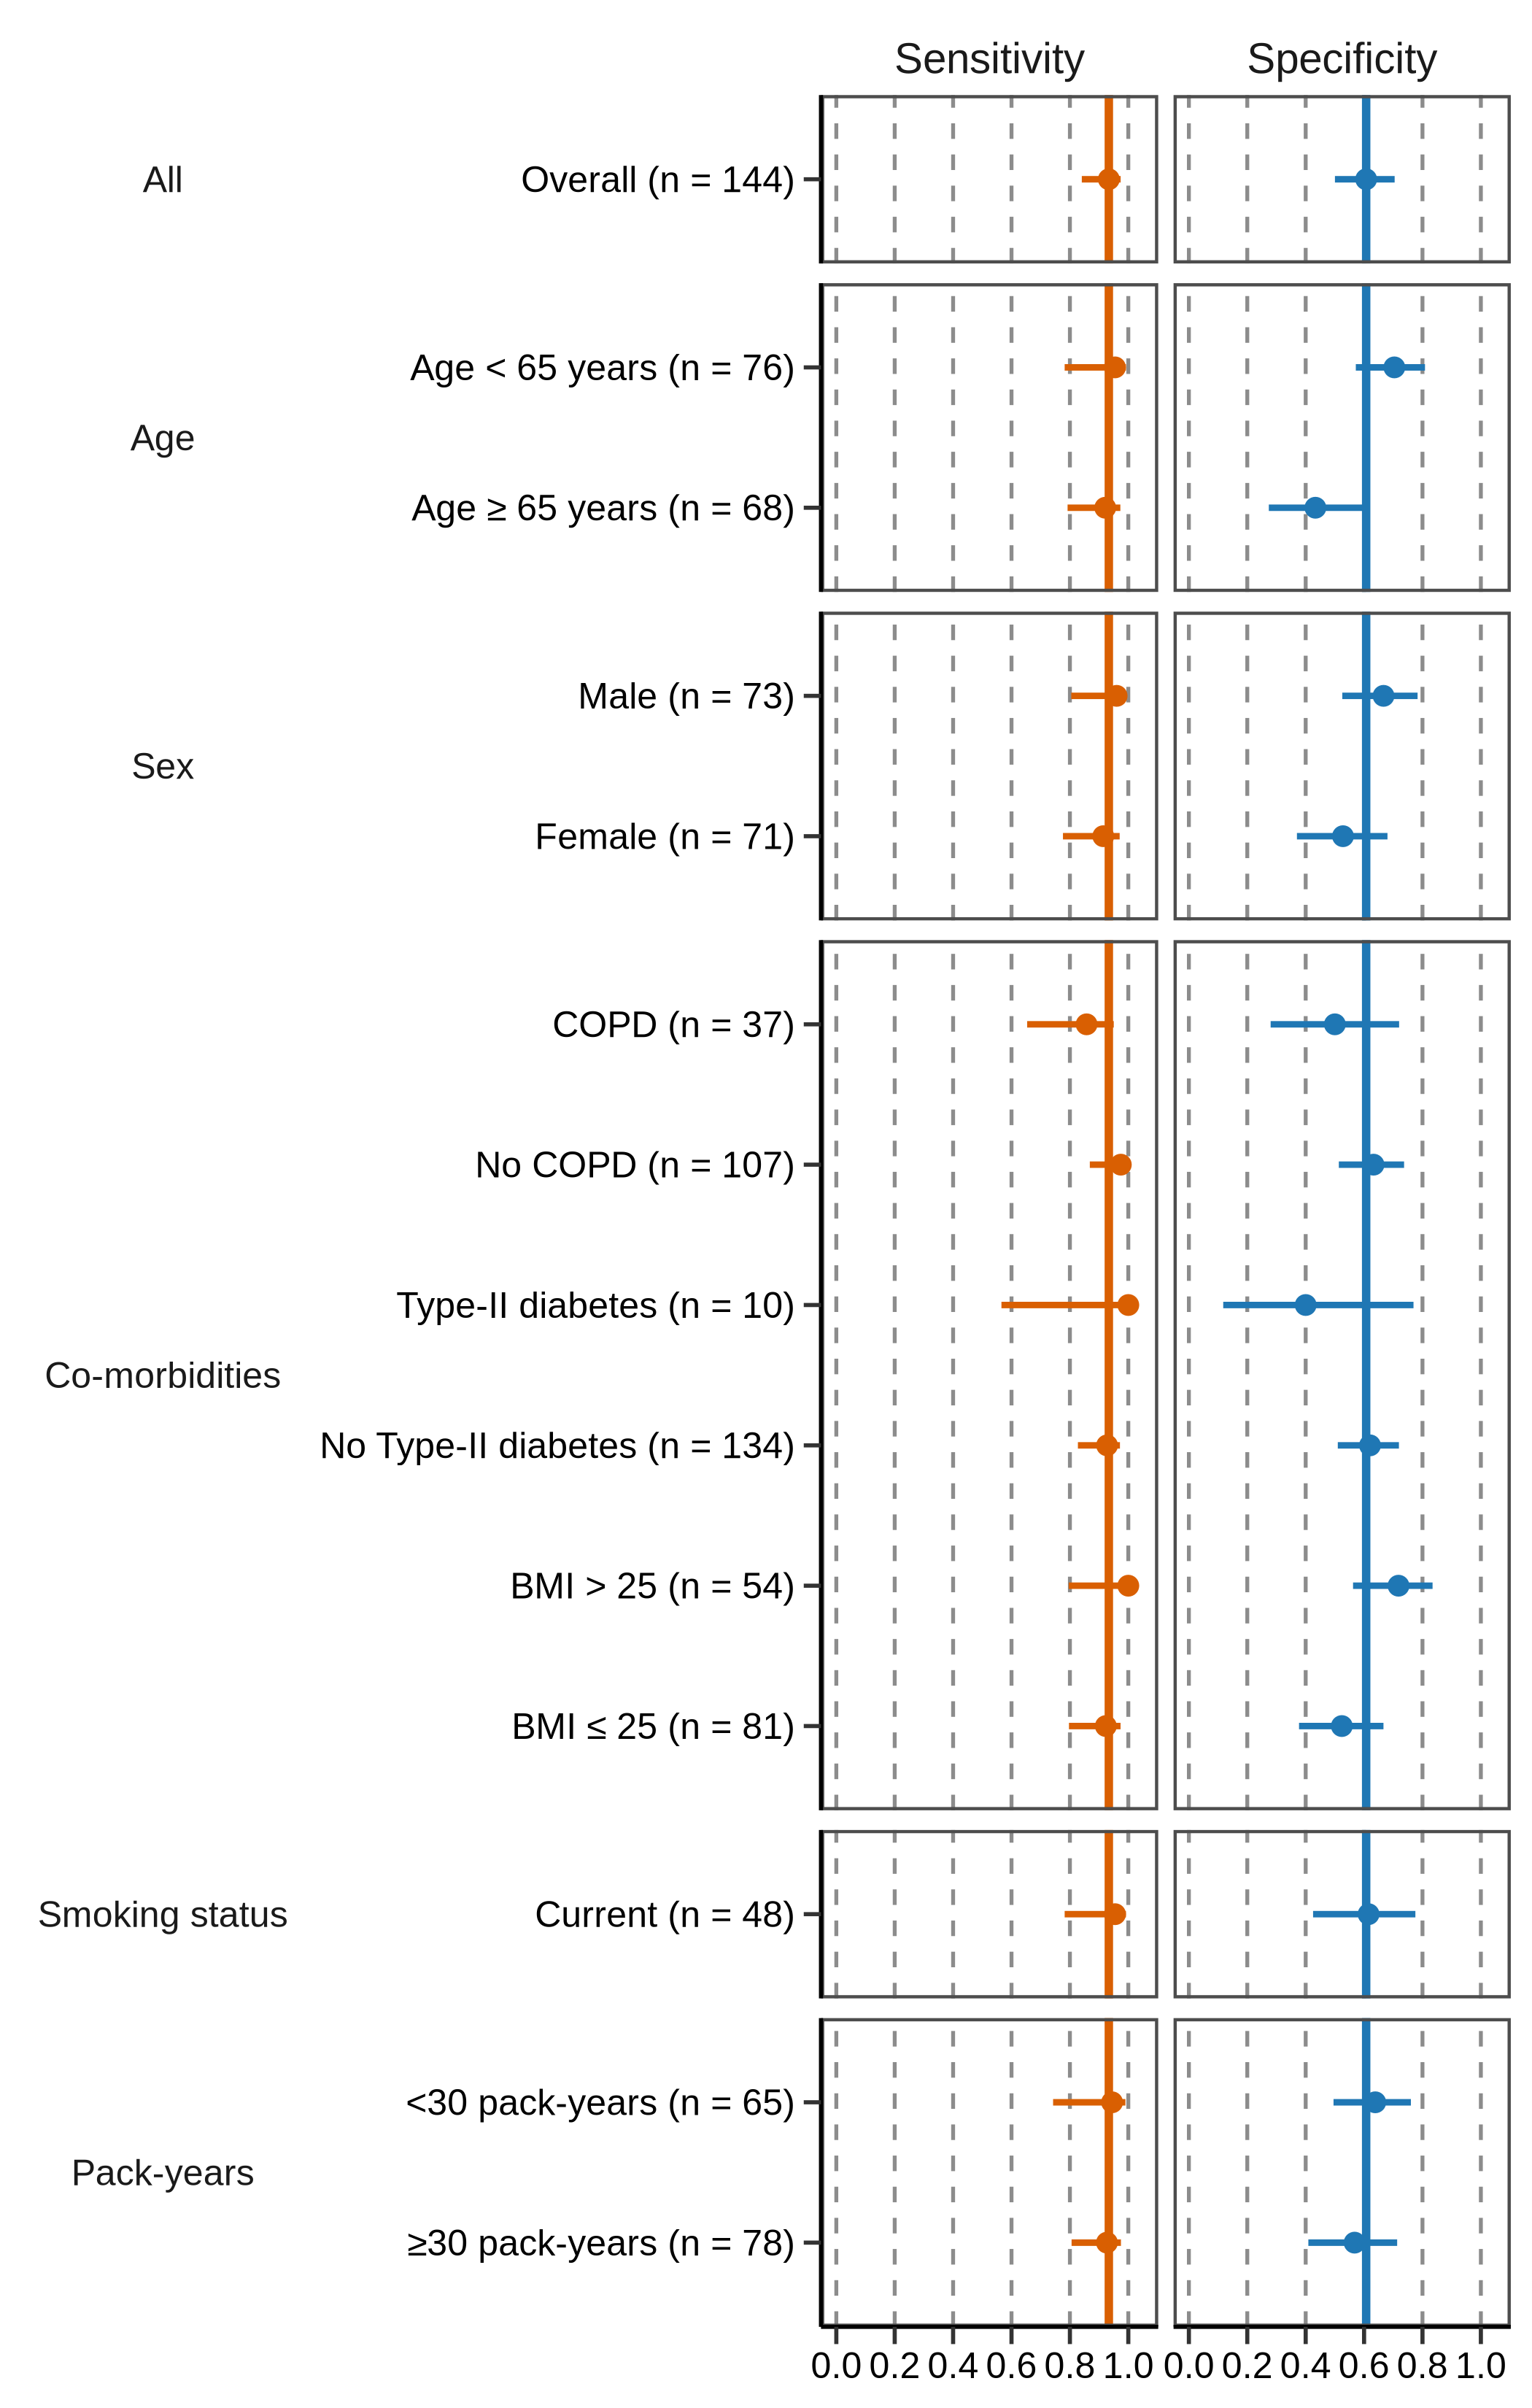

In [16]:
out <- create_lucas_clinical_subgroup_figure(
  scores_df        = train,
  meta             = meta,
  lucas_df         = lucas_df,
  specificity_cutoff = 0.60,
  locked_threshold = locked_threshold,
  se_level         = 0.95
)
out$plot
#out$subgroup_data

In [18]:
ggsave(
  filename = "../../outputs/Extended/Ext-Data-Fig-9-LUCAS-subgroup_figure_sens_spec.png",
  plot = out$plot,
  width = 8,
  height = 12,
  dpi = 600,
  bg = "white"
)

# Extended Data Fig. 10

In [17]:
# =====================================================================
# Rebuild cv_perf (stage-weighted CV performance across models x thresholds)
# =====================================================================

STAGE_W   <- c(I = 0.546, II = 0.075, III = 0.218, IV = 0.160)
train_idx <- c(DELFI = 1, Proteomics = 2, `DELFI-Pro` = 3)
SPEC_GRID <- c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95)

wilson <- function(x, n, conf = 0.95) {
    if (n == 0) return(c(NA, NA))
    z <- qnorm(1 - (1 - conf) / 2); p <- x / n
    ctr <- (p + z^2 / (2 * n)) / (1 + z^2 / n)
    hw  <- z * sqrt(p * (1 - p) / n + z^2 / (4 * n^2)) / (1 + z^2 / n)
    c(max(0, ctr - hw), min(1, ctr + hw))
}

cv_operating_point <- function(df, spec_target, weights = STAGE_W, B = 4000) {
    df   <- df %>% filter(!is.na(score))
    ctrl <- df %>% filter(class == "No cancer")
    case <- df %>% filter(class == "Cancer", stage %in% names(weights))

    r   <- pROC::roc(class ~ score, data = df, quiet = TRUE)
    thr <- tibble(spec = r$specificities, thr = r$thresholds) %>%
        filter(spec >= spec_target) %>% arrange(spec) %>% slice(1) %>% pull(thr)

    st <- case %>% group_by(stage) %>%
        summarise(n = n(), tp = sum(score >= thr), sens = tp / n, .groups = "drop") %>%
        mutate(lo = map2_dbl(tp, n, ~ wilson(.x, .y)[1]),
               hi = map2_dbl(tp, n, ~ wilson(.x, .y)[2]))

    w       <- weights[st$stage] / sum(weights[st$stage])
    sens_wt <- sum(w * st$sens)

    bs <- rowSums(sapply(seq_len(nrow(st)),
                         function(k) w[k] * rbinom(B, st$n[k], st$sens[k]) / st$n[k]))

    n_ctrl <- nrow(ctrl); tn <- sum(ctrl$score < thr)
    tibble(spec_target = spec_target, threshold = thr,
           n_ctrl = n_ctrl, spec = tn / n_ctrl,
           spec_lo = wilson(tn, n_ctrl)[1], spec_hi = wilson(tn, n_ctrl)[2],
           n_case = nrow(case),
           sens_raw = mean(case$score >= thr),
           sens_wt  = sens_wt,
           sens_wt_lo = quantile(bs, 0.025), sens_wt_hi = quantile(bs, 0.975),
           per_stage = list(st))
}

cv_perf <- expand_grid(model = names(train_idx), spec_target = SPEC_GRID) %>%
    mutate(res = map2(model, spec_target,
                      ~ cv_operating_point(overall.list[[train_idx[[.x]]]], .y))) %>%
    unnest(res, names_repair = "unique") %>%
    select(-spec_target...2) %>% rename(spec_target = spec_target...3)

New names:
• `spec_target` -> `spec_target...2`
• `spec_target` -> `spec_target...3`


[1] 0.8608992

2.5% 
0.6908403

97.5% 
0.9944772

[1] "model"       "spec_target" "threshold"   "n_ctrl"      "spec"       
 [6] "spec_lo"     "spec_hi"     "n_case"      "sens_raw"    "sens_wt"    
[11] "sens_wt_lo"  "sens_wt_hi"  "per_stage"

[1] 0.6071429

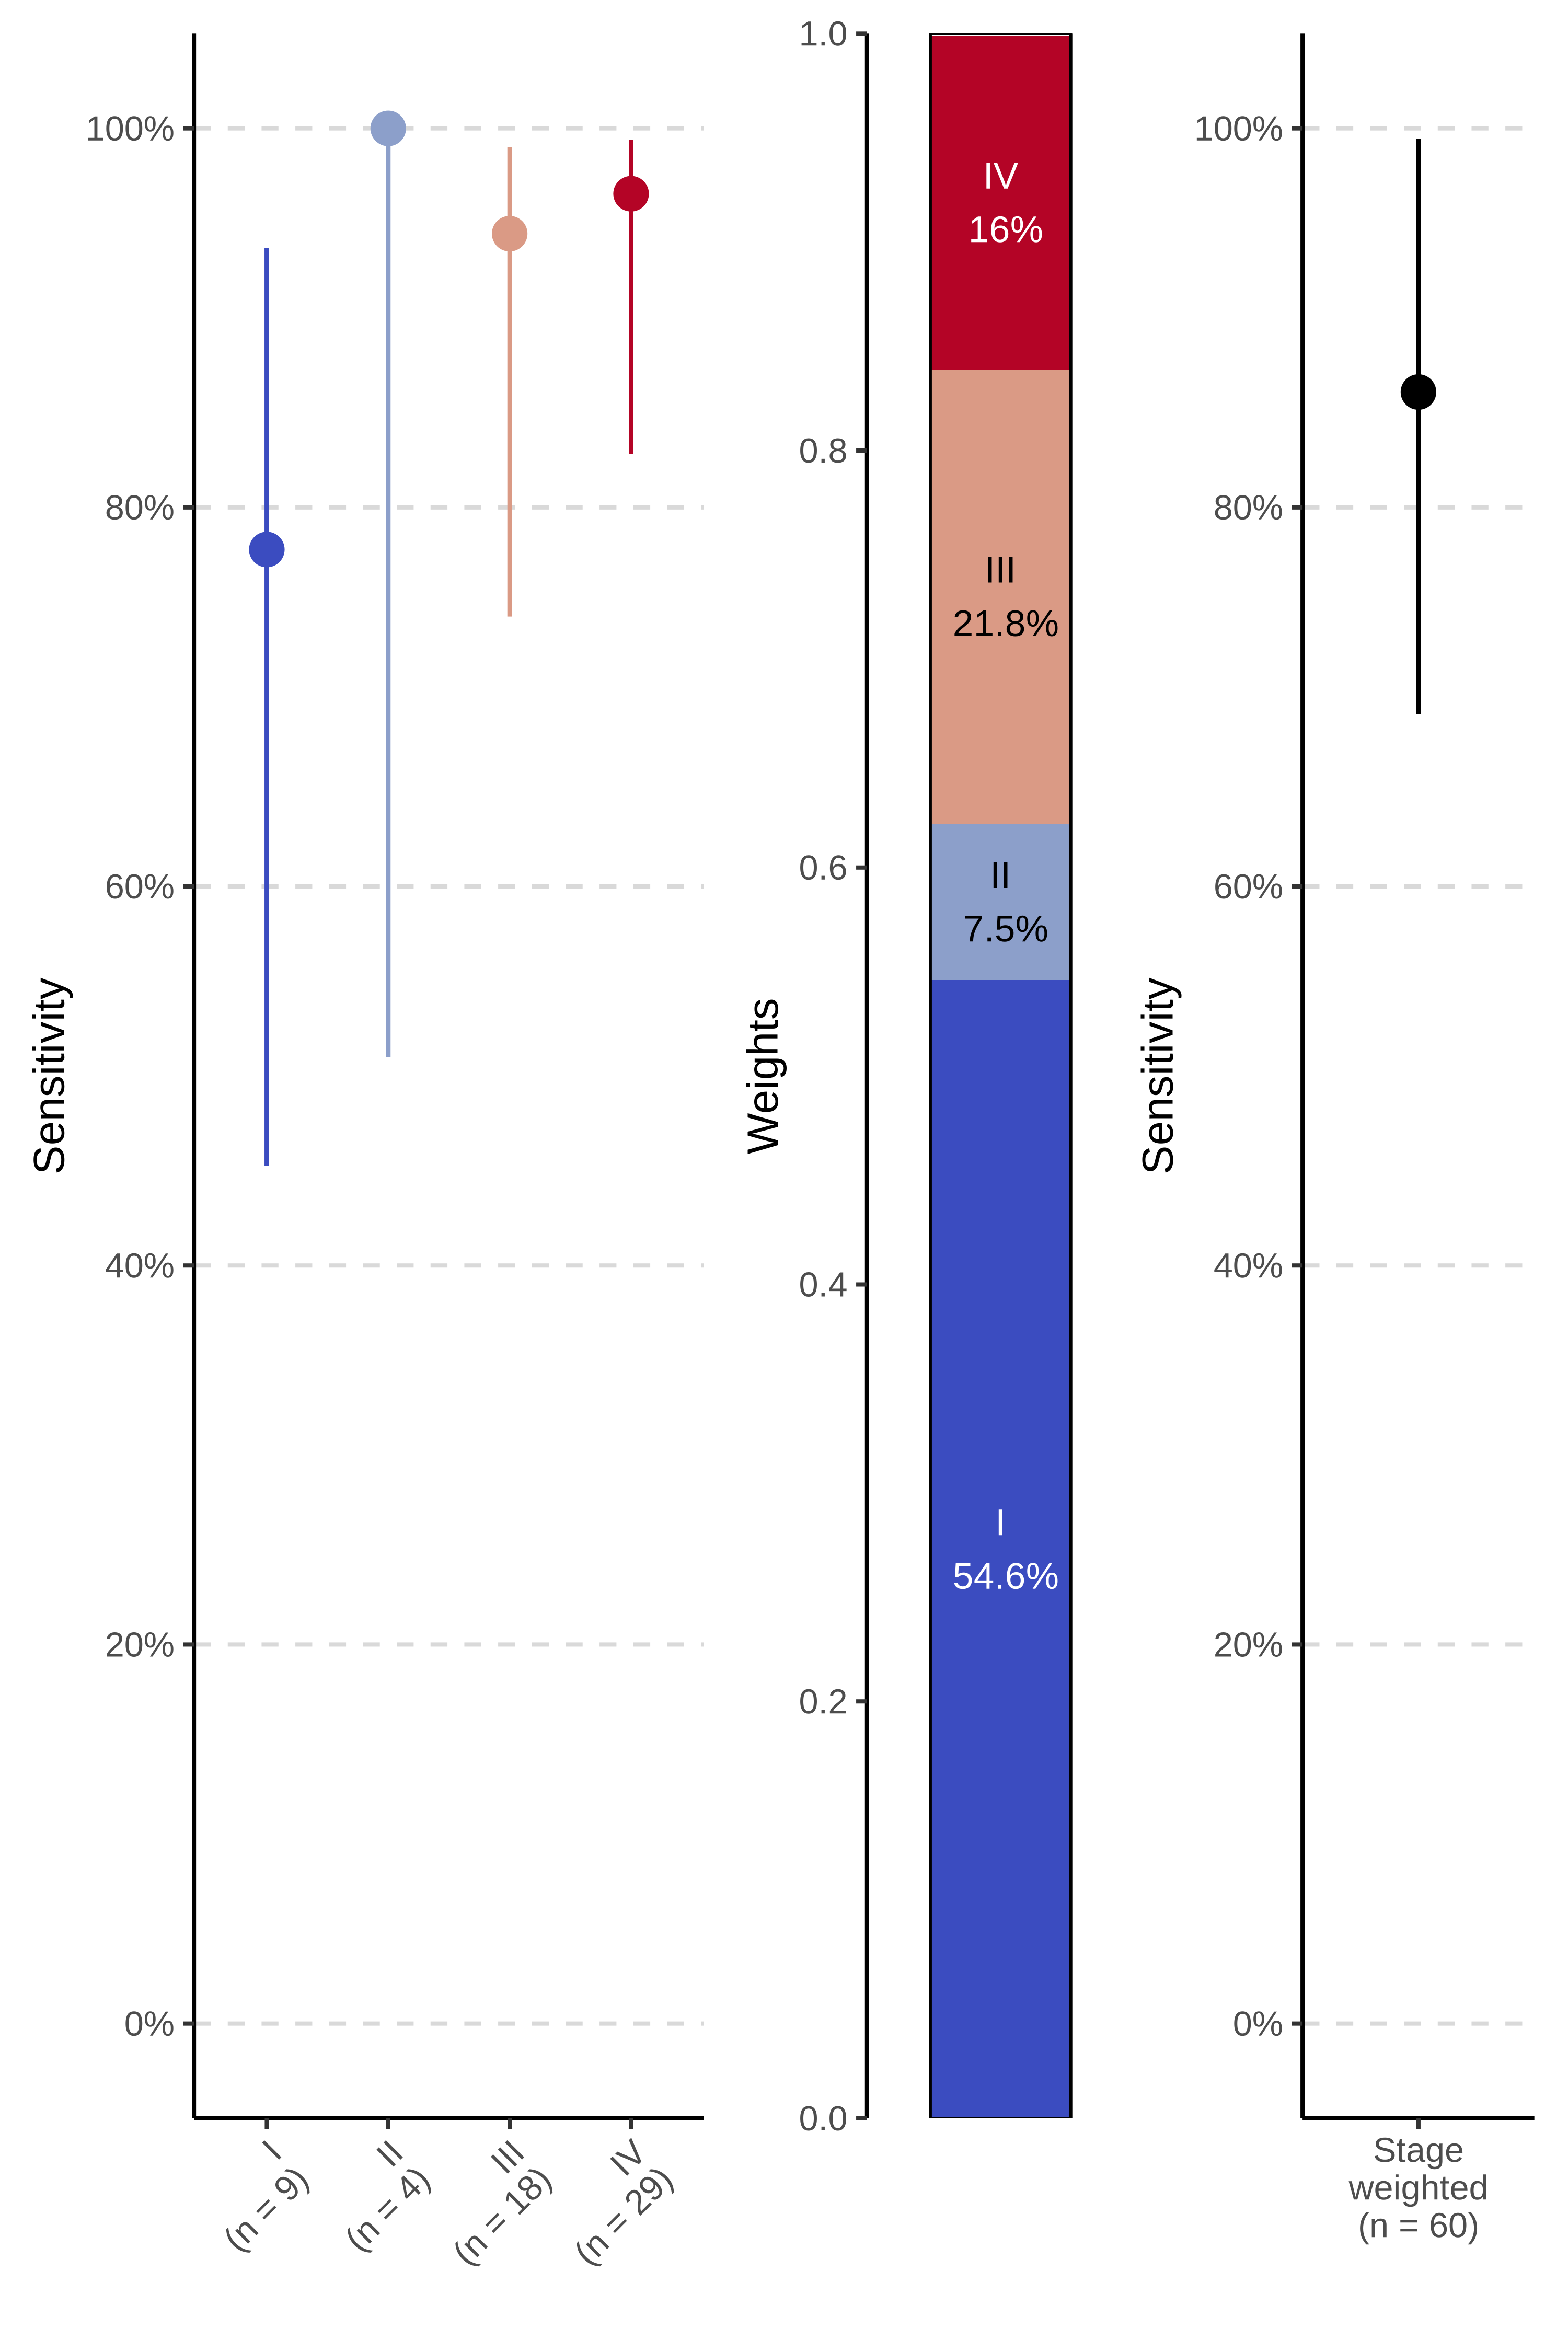

In [18]:
stage_colors <- c(I = "#3B4CC0", II = "#8C9FCA", III = "#DA9A85", IV = "#B40426")


make_stage_weighted_figure <- function(cv_perf, model_name, spec_target = 0.60,
                                        weights = STAGE_W,
                                        stage_colors = c(I = "#3B4CC0", II = "#8C9FCA",
                                                          III = "#DA9A85", IV = "#B40426")) {

    row <- cv_perf %>% filter(model == model_name, spec_target == !!spec_target)
    per_stage <- row$per_stage[[1]] %>%
        mutate(stage = factor(stage, levels = c("I", "II", "III", "IV")))

    n_total <- sum(per_stage$n)

    # ---- Panel A: sensitivity by stage --------------------------------
    pA <- per_stage %>%
        ggplot(aes(stage, sens, color = stage)) +
        geom_linerange(aes(ymin = lo, ymax = hi), linewidth = 1) +
        geom_point(size = 7) +
        scale_color_manual(values = stage_colors, guide = "none") +
        scale_x_discrete(labels = paste0(per_stage$stage, "\n(n = ", per_stage$n, ")")) +
        scale_y_continuous("Sensitivity", limits = c(0, 1), breaks = seq(0, 1, 0.2),
                            labels = scales::percent_format(accuracy = 1)) +
        theme_classic(base_size = 20) +
        theme(axis.title.x = element_blank(),
              axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
              panel.grid.major.y = element_line(color = "gray85", linetype = "dashed"))

    # ---- Panel B: stage weights ----------------------------------------
    wdf <- tibble(stage = names(weights), weight = as.numeric(weights)) %>%
        filter(stage %in% per_stage$stage) %>%
        mutate(stage = factor(stage, levels = c("I", "II", "III", "IV"))) %>%
        arrange(stage) %>%
        mutate(ymax = cumsum(weight), ymin = lag(ymax, default = 0),
               ylabel = (ymin + ymax) / 2,
               label = paste0(stage, "\n ", round(100 * weight, 1), "%"))

    dark_stages <- c("I", "IV")
    wdf <- wdf %>% mutate(text_color = ifelse(stage %in% dark_stages, "white", "black"))

    pB <- ggplot(wdf) +
        # internal segments: no border, so no seams inside the bar
        geom_rect(aes(xmin = 0.7, xmax = 1.5, ymin = ymin, ymax = ymax, fill = stage)) +
        # single outline around the whole stacked bar
        geom_rect(xmin = 0.7, xmax = 1.5, ymin = 0, ymax = 1,
                  fill = NA, color = "black", linewidth = 0.6) +
        geom_text(aes(x = 1.1, y = ylabel, label = label, color = I(text_color)), size = 6) +
        scale_fill_manual(values = stage_colors, guide = "none") +
        scale_y_continuous("Weights", limits = c(0, 1), breaks = seq(0, 1, 0.2),
                            expand = c(0, 0)) +
        scale_x_continuous("", breaks = NULL, limits = c(0.4, 1.6)) +
        theme_classic(base_size = 20) +
        theme(axis.text.x = element_blank(), axis.ticks.x = element_blank(),
              axis.title.x = element_text(margin = margin(t = 2)))

    # ---- Panel C: stage-weighted sensitivity ---------------------------
    pC <- tibble(x = "Stage\nweighted", sens = row$sens_wt,
                 lo = row$sens_wt_lo, hi = row$sens_wt_hi) %>%
        ggplot(aes(x, sens)) +
        geom_linerange(aes(ymin = lo, ymax = hi), linewidth = 1, color = "black") +
        geom_point(size = 7, color = "black") +
        scale_x_discrete(labels = paste0("Stage\nweighted\n(n = ", n_total, ")")) +
        scale_y_continuous("Sensitivity", limits = c(0, 1), breaks = seq(0, 1, 0.2),
                            labels = scales::percent_format(accuracy = 1)) +
        theme_classic(base_size = 20) +
        theme(axis.title.x = element_blank(),
              panel.grid.major.y = element_line(color = "gray85", linetype = "dashed"))

    # ---- Assemble, no title ---------------------------------------------
    pA + pB + pC + plot_layout(widths = c(2.2, 1, 1))
}


options(repr.plot.width = 10, repr.plot.height = 15, repr.plot.res = 300)


fig_C_delfi_pro <- make_stage_weighted_figure(cv_perf, "DELFI-Pro", spec_target = 0.60)
fig_C_delfi_pro

row <- cv_perf %>% filter(model == "DELFI-Pro", spec_target == 0.60)
row$sens_wt
row$sens_wt_lo
row$sens_wt_hi

row <- cv_perf %>% filter(model == "DELFI-Pro", spec_target == 0.60)
names(row)   # see what columns are available
row$spec     # or whatever the actual specificity column is called

In [21]:
ggsave("../../outputs/Extended/Ext-Data-Fig-10-Stage_weighted_DELFI-Pro_60spec_TRAINING.png",
       plot = fig_C_delfi_pro, width = 10, height = 12, dpi = 600)

## PPV and NPV

In [19]:
# =====================================================================
# Setup constants (run once per session — restore if kernel restarted)
# =====================================================================
STAGE_W   <- c(I = 0.546, II = 0.075, III = 0.218, IV = 0.160)  # NLST first-screen weights
train_idx <- c(DELFI = 1, Proteomics = 2, `DELFI-Pro` = 3)
PREV      <- 0.007   # detectable lung cancer prevalence, USPSTF-eligible population
SPEC_GRID <- c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95)

# =====================================================================
# PPV / NPV figure across specificity thresholds and models
# Mazzone-style nonparametric bootstrap: resample subjects, recompute
# stage-weighted sensitivity + specificity, derive PPV/NPV each iteration
# =====================================================================

## ---- one bootstrap replicate: resample cases and controls separately ----
bootstrap_replicate <- function(ctrl, case, thr, weights) {
    ctrl_bs <- ctrl[sample.int(nrow(ctrl), replace = TRUE), ]
    case_bs <- case[sample.int(nrow(case), replace = TRUE), ]

    spec_bs <- mean(ctrl_bs$score < thr)

    st_bs <- case_bs %>% group_by(stage) %>%
        summarise(n = n(), tp = sum(score >= thr), sens = tp / n, .groups = "drop")
    w_bs  <- weights[st_bs$stage] / sum(weights[st_bs$stage])
    sens_wt_bs <- sum(w_bs * st_bs$sens)

    c(spec = spec_bs, sens_wt = sens_wt_bs)
}

## ---- full pipeline: lock threshold once, bootstrap Se/Sp, derive PPV/NPV ----
ppv_npv_mazzone_bootstrap <- function(df, spec_target, prevalence = PREV,
                                       weights = STAGE_W, B = 2000) {

    df   <- df %>% filter(!is.na(score))
    ctrl <- df %>% filter(class == "No cancer")
    case <- df %>% filter(class == "Cancer", stage %in% names(weights))

    # threshold locked once on the full (non-resampled) data
    r   <- pROC::roc(class ~ score, data = df, quiet = TRUE)
    thr <- tibble(spec = r$specificities, thr = r$thresholds) %>%
        filter(spec >= spec_target) %>% arrange(spec) %>% slice(1) %>% pull(thr)

    # point estimates on the observed data
    spec_pt <- mean(ctrl$score < thr)
    st_pt   <- case %>% group_by(stage) %>%
        summarise(n = n(), tp = sum(score >= thr), sens = tp / n, .groups = "drop")
    w_pt      <- weights[st_pt$stage] / sum(weights[st_pt$stage])
    sens_wt_pt <- sum(w_pt * st_pt$sens)

    ppv_pt <- prevalence * sens_wt_pt /
        (prevalence * sens_wt_pt + (1 - prevalence) * (1 - spec_pt))
    npv_pt <- (1 - prevalence) * spec_pt /
        ((1 - prevalence) * spec_pt + prevalence * (1 - sens_wt_pt))

    # bootstrap replicates, same threshold applied each time
    boot <- replicate(B, bootstrap_replicate(ctrl, case, thr, weights))
    spec_boot    <- boot["spec", ]
    sens_wt_boot <- boot["sens_wt", ]

    ppv_boot <- prevalence * sens_wt_boot /
        (prevalence * sens_wt_boot + (1 - prevalence) * (1 - spec_boot))
    npv_boot <- (1 - prevalence) * spec_boot /
        ((1 - prevalence) * spec_boot + prevalence * (1 - sens_wt_boot))

    tibble(
        spec_target = spec_target, threshold = thr,
        spec = spec_pt, sens_wt = sens_wt_pt,
        ppv = ppv_pt, ppv_lo = quantile(ppv_boot, 0.025), ppv_hi = quantile(ppv_boot, 0.975),
        npv = npv_pt, npv_lo = quantile(npv_boot, 0.025), npv_hi = quantile(npv_boot, 0.975)
    )
}

## ---- run across models x specificity grid ------------------------------
ppv_npv_grid <- expand_grid(model = names(train_idx), spec_target = SPEC_GRID) %>%
    mutate(res = map2(model, spec_target,
                      ~ ppv_npv_mazzone_bootstrap(overall.list[[train_idx[[.x]]]], .y))) %>%
    select(-spec_target) %>%
    unnest(res)

## ---- figure: PPV (top) / NPV (bottom), x = specificity, color = model --
model_colors <- setNames(pal_nejm()(length(train_idx)), names(train_idx))

pPPV <- ppv_npv_grid %>%
    ggplot(aes(factor(spec_target), 100 * ppv, color = model, group = model)) +
    geom_hline(yintercept = 100 * PREV, linetype = "dashed", color = "gray60") +
    geom_linerange(aes(ymin = 100 * ppv_lo, ymax = 100 * ppv_hi),
                   position = position_dodge(width = 0.5), linewidth = 1) +
    geom_point(position = position_dodge(width = 0.5), size = 3) +
    scale_color_manual(values = model_colors, name = NULL) +
    scale_y_continuous("PPV (%)", limits = c(0, NA)) +
    scale_x_discrete("Specificity threshold", labels = scales::percent(SPEC_GRID)) +
    theme_classic(base_size = 14) +
    theme(legend.position = "top",
          panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"))

pNPV <- ppv_npv_grid %>%
    ggplot(aes(factor(spec_target), 100 * npv, color = model, group = model)) +
    geom_hline(yintercept = 100 * (1 - PREV), linetype = "dashed", color = "gray60") +
    geom_linerange(aes(ymin = 100 * npv_lo, ymax = 100 * npv_hi),
                   position = position_dodge(width = 0.5), linewidth = 1) +
    geom_point(position = position_dodge(width = 0.5), size = 3) +
    scale_color_manual(values = model_colors, guide = "none") +
    scale_y_continuous("NPV (%)", limits = c(95, 100)) +
    scale_x_discrete("Specificity threshold", labels = scales::percent(SPEC_GRID)) +
    theme_classic(base_size = 14) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"))

fig_ppv_npv <- pPPV / pNPV + plot_layout(heights = c(1, 1))


In [ ]:
# =====================================================================
# PPV / NPV — DELFI-Pro only, at 60% specificity
# Styled to match the full PPV/NPV-by-specificity figure
# =====================================================================
ppv_npv_delfipro_60 <- ppv_npv_grid %>%
    filter(model == "DELFI-Pro", spec_target == 0.60)

ppv_npv_delfipro_60 %>%
    select(model, spec_target, threshold, spec, sens_wt,
           ppv, ppv_lo, ppv_hi, npv, npv_lo, npv_hi) %>%
    mutate(across(c(spec, sens_wt, ppv, ppv_lo, ppv_hi, npv, npv_lo, npv_hi),
                  ~ round(100 * .x, 2)))

pPPV_dp60 <- ppv_npv_delfipro_60 %>%
    ggplot(aes(model, 100 * ppv)) +
    geom_hline(yintercept = 100 * PREV, linetype = "dashed", color = "gray60") +
    geom_linerange(aes(ymin = 100 * ppv_lo, ymax = 100 * ppv_hi),
                   linewidth = 1, color = model_colors[["DELFI-Pro"]]) +
    geom_point(size = 4, color = model_colors[["DELFI-Pro"]]) +
    scale_y_continuous("PPV (%)", limits = c(0, 5)) +
    scale_x_discrete(NULL) +
    theme_classic(base_size = 20) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"))

pNPV_dp60 <- ppv_npv_delfipro_60 %>%
    ggplot(aes(model, 100 * npv)) +
    geom_hline(yintercept = 100 * (1 - PREV), linetype = "dashed", color = "gray60") +
    geom_linerange(aes(ymin = 100 * npv_lo, ymax = 100 * npv_hi),
                   linewidth = 1, color = model_colors[["DELFI-Pro"]]) +
    geom_point(size = 4, color = model_colors[["DELFI-Pro"]]) +
    scale_y_continuous("NPV (%)", limits = c(97, 100)) +
    scale_x_discrete(NULL) +
    theme_classic(base_size = 20) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"))

fig_ppv_npv_delfipro60 <- pPPV_dp60 / pNPV_dp60 +
    plot_layout(nrow = 2) +
    plot_annotation(
        title = "",
        subtitle = "",
        theme = theme(plot.title = element_text(size = 14, face = "bold"))
    )

fig_ppv_npv_delfipro60


ppv_npv_delfipro_60 %>%
    select(npv, npv_lo, npv_hi) %>%
    mutate(across(everything(), ~ round(100 * .x, 2)))

## LDCT NNS and False Positives

NNS baseline (no test): 143
NNS positive: 66 (47-90)
NNS negative: 620 (281-14243)
RR: 9.4
PPV: 1.52%  NPV: 99.84%  Sens(wt): 86.1%  Spec: 60.7%


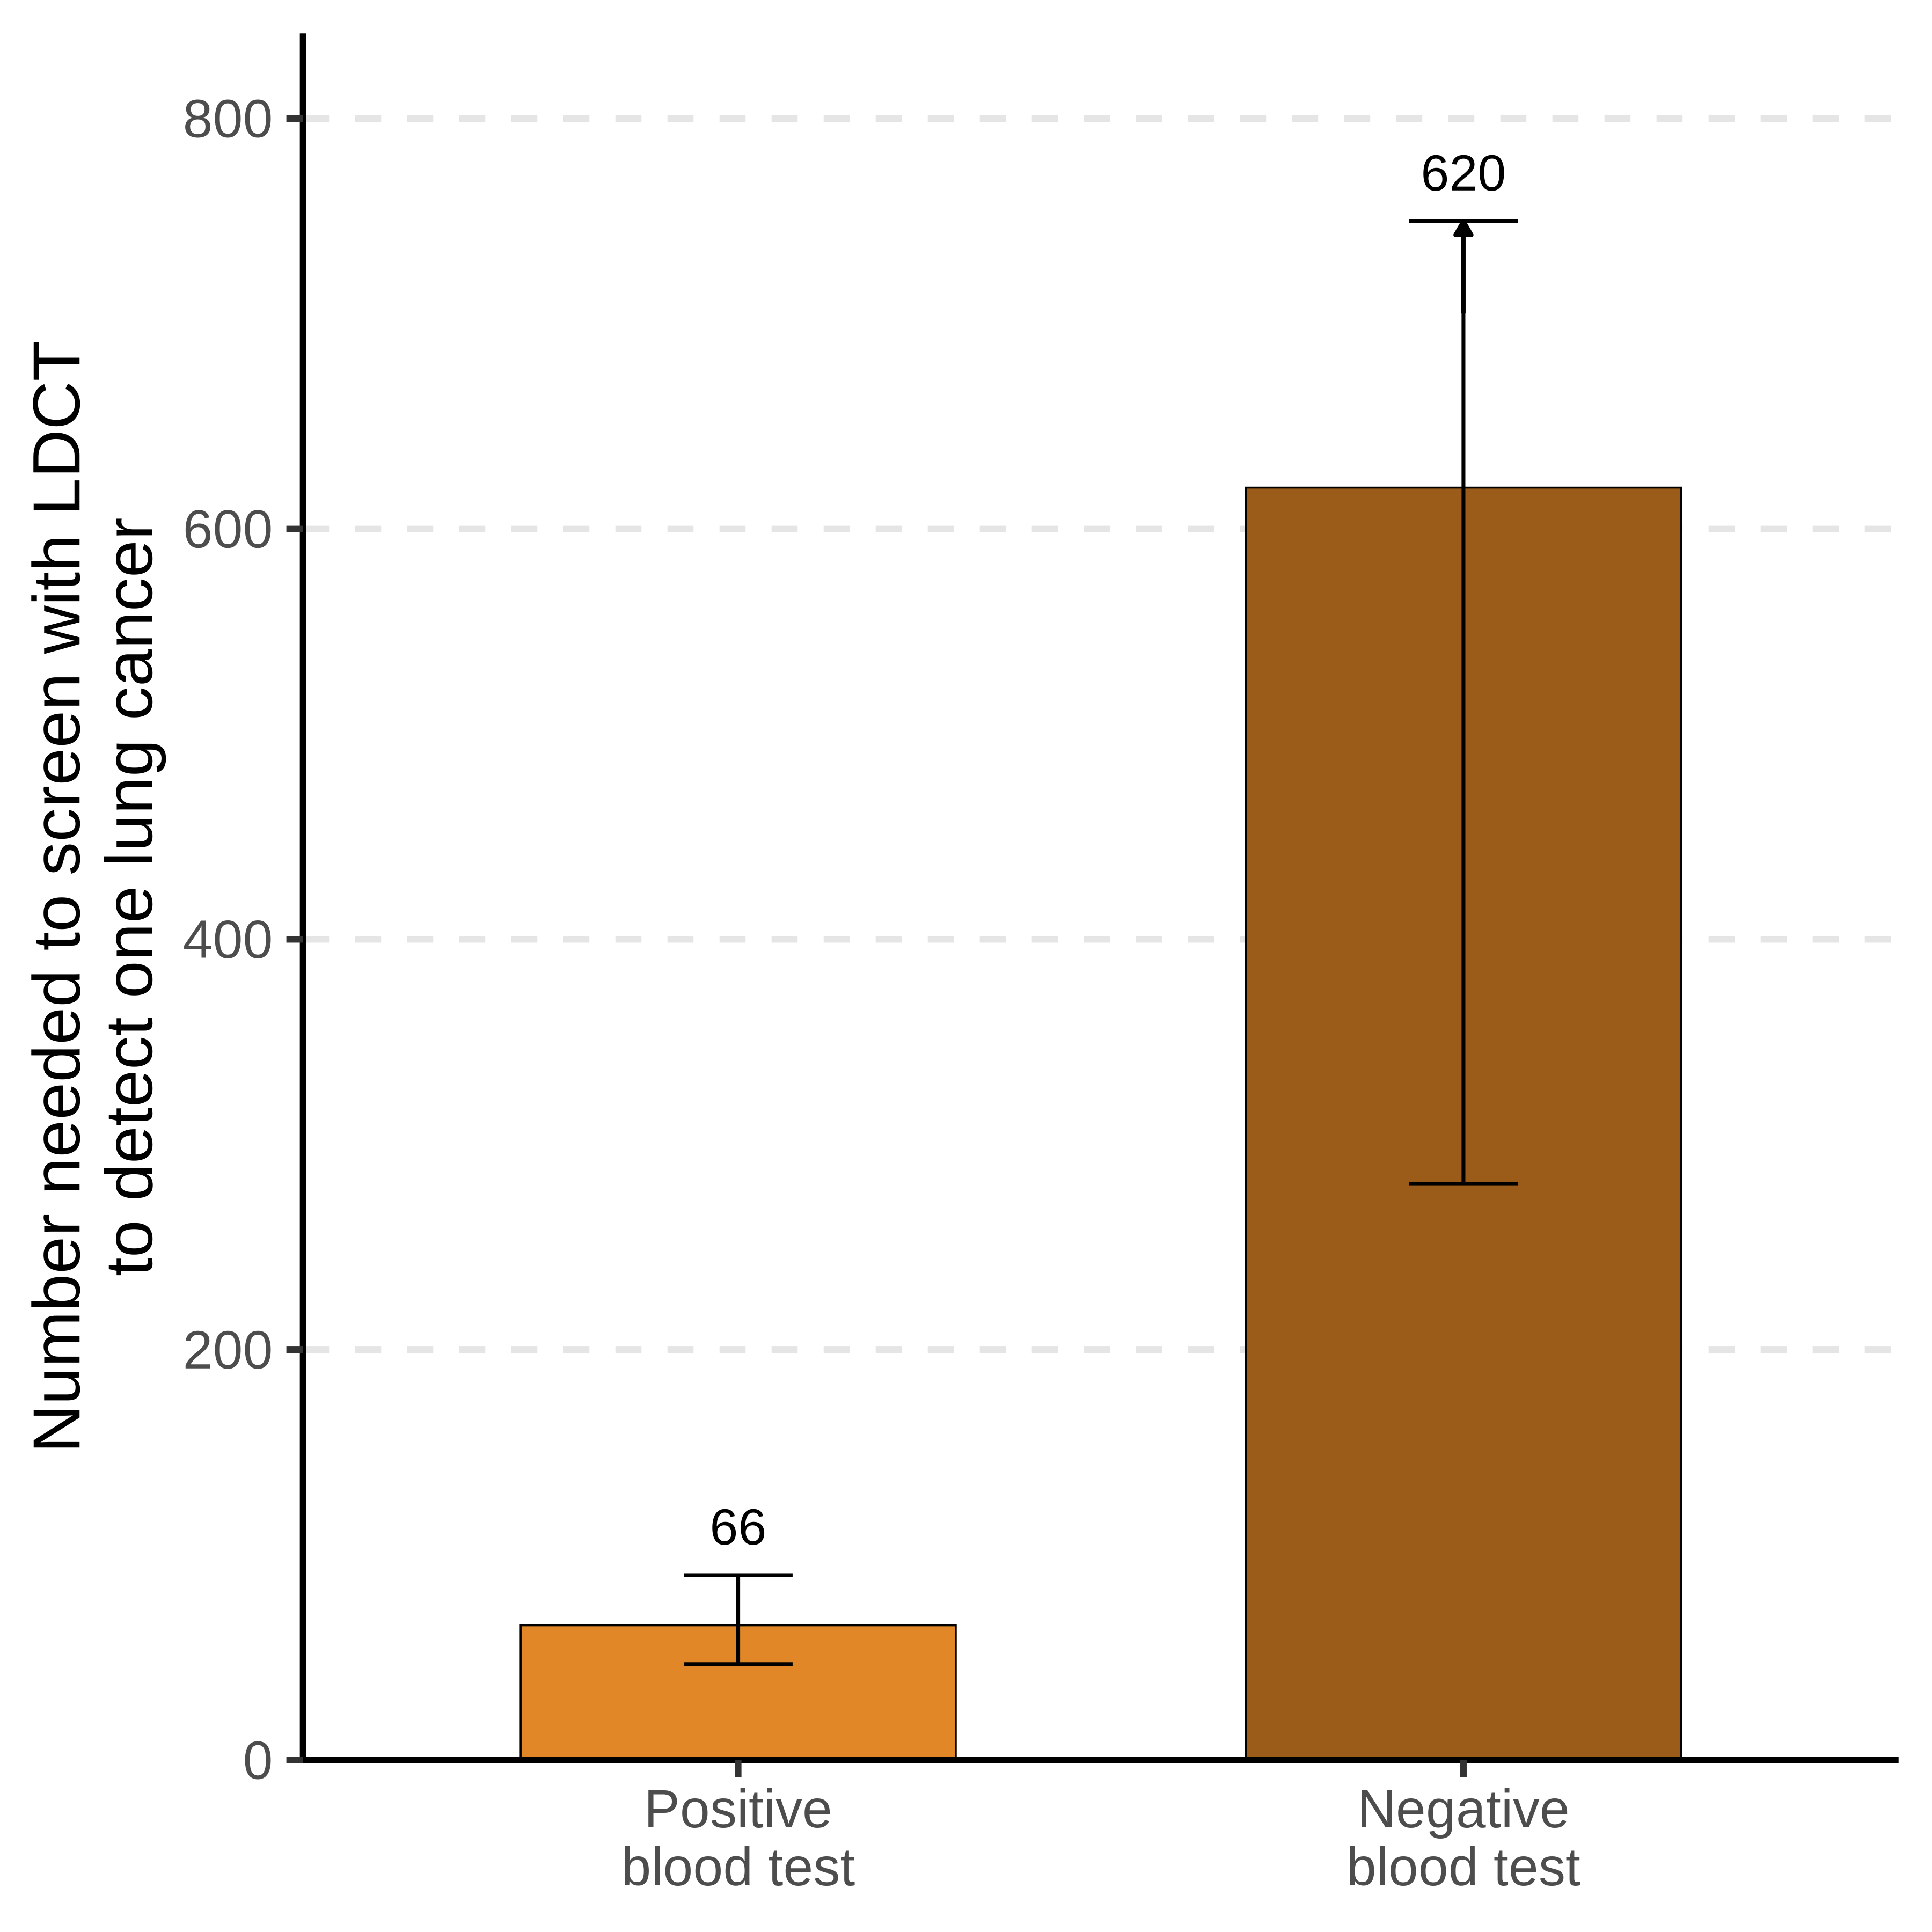

In [33]:
# =====================================================================
#  NNS with LDCT to detect one lung cancer + false-positive burden
#  DELFI-Pro @ 60% specificity
#  NNS defined as in Mazzone et al. (Cancer Discov 2024): 1/PPV for a
#  positive test, 1/(1-NPV) for a negative test, 1/prevalence untested.
# =====================================================================

# "bar"  -> LDCT alone (143) shown as its own bar (as in Mazzone Fig. 4D)
# "line" -> baseline hidden as a bar, drawn as a dashed reference line
#           so the 66 and 620 bars still have their comparator
# "none" -> baseline omitted entirely
SHOW_BASELINE <- "none"

stopifnot(SHOW_BASELINE %in% c("bar", "line", "none"))

ppv_npv_delfipro_60 <- ppv_npv_grid %>%
    filter(model == "DELFI-Pro", spec_target == 0.60)

dp60 <- ppv_npv_delfipro_60

ldct_burden <- dp60 %>%
    transmute(
        model, spec_target, threshold,
        spec, sens_wt, ppv, npv,

        # 1/PPV is decreasing in PPV -> bounds swap
        nns_pos      = 1 / ppv,
        nns_pos_lo   = 1 / ppv_hi,
        nns_pos_hi   = 1 / ppv_lo,

        # 1/(1-NPV) is increasing in NPV -> bounds do NOT swap
        nns_neg      = 1 / (1 - npv),
        nns_neg_lo   = 1 / (1 - npv_lo),
        nns_neg_hi   = 1 / (1 - npv_hi),

        nns_baseline = 1 / PREV,
        rr           = nns_neg / nns_pos,

        fp_per_1000_tested    = (1 - PREV) * (1 - spec) * 1000,
        fp_per_tp             = (1 - ppv) / ppv,
        pct_positive_are_fp   = 1 - ppv
    )

# ---- numbers for the legend / Results ----
with(ldct_burden, cat(sprintf(
    "NNS baseline (no test): %.0f\nNNS positive: %.0f (%.0f-%.0f)\nNNS negative: %.0f (%.0f-%.0f)\nRR: %.1f\nPPV: %.2f%%  NPV: %.2f%%  Sens(wt): %.1f%%  Spec: %.1f%%\n",
    nns_baseline, nns_pos, nns_pos_lo, nns_pos_hi,
    nns_neg, nns_neg_lo, nns_neg_hi, rr,
    100 * ppv, 100 * npv, 100 * sens_wt, 100 * spec)))

BASELINE_LAB <- "LDCT alone\n(no test)"

nns_df_all <- tibble(
    group = factor(c(BASELINE_LAB, "Positive\nblood test", "Negative\nblood test"),
                   levels = c(BASELINE_LAB, "Positive\nblood test", "Negative\nblood test")),
    nns   = c(ldct_burden$nns_baseline, ldct_burden$nns_pos, ldct_burden$nns_neg),
    lo    = c(ldct_burden$nns_baseline, ldct_burden$nns_pos_lo, ldct_burden$nns_neg_lo),
    hi    = c(ldct_burden$nns_baseline, ldct_burden$nns_pos_hi, ldct_burden$nns_neg_hi)
)

stopifnot(all(nns_df_all$lo <= nns_df_all$nns), all(nns_df_all$nns <= nns_df_all$hi))

# drop the baseline row unless it is being drawn as a bar; droplevels() keeps
# the x axis from leaving an empty slot where the bar used to be
nns_df <- if (SHOW_BASELINE == "bar") nns_df_all else
    nns_df_all %>% filter(group != BASELINE_LAB) %>% mutate(group = droplevels(group))

bar_colors <- c("gray70",
                model_colors[["DELFI-Pro"]],
                colorspace::darken(model_colors[["DELFI-Pro"]], 0.3))
names(bar_colors) <- levels(nns_df_all$group)

# ---- clip the uninformative upper tail so it doesn't drive the axis ------
Y_MAX <- 750              # top of the plotted data range (arrow tip sits here)
Y_TOP <- Y_MAX * 1.10     # axis ceiling, leaves room for the label above the arrow

nns_df <- nns_df %>%
    mutate(hi_clip = pmin(hi, Y_MAX),
           clipped = hi > Y_MAX)

pNNS <- nns_df %>%
    ggplot(aes(group, nns, fill = group)) +
    # baseline as a reference line when it is not drawn as a bar
    { if (SHOW_BASELINE == "line")
        geom_hline(yintercept = ldct_burden$nns_baseline,
                   linetype = "dashed", colour = "gray40", linewidth = 0.7)
      else NULL } +
    { if (SHOW_BASELINE == "line")
        annotate("text", x = 0.55, y = ldct_burden$nns_baseline + Y_MAX * 0.02,
                 label = sprintf("LDCT alone: %.0f", ldct_burden$nns_baseline),
                 hjust = 0, vjust = 0, size = 8, colour = "gray40")
      else NULL } +
    geom_col(width = 0.6, color = "black", linewidth = 0.4) +
    geom_errorbar(aes(ymin = pmax(lo, 1), ymax = hi_clip),
                  width = 0.15, linewidth = 0.8, color = "black",
                  data = filter(nns_df, group != BASELINE_LAB)) +
    # arrow where the interval was clipped
    geom_segment(aes(x = group, xend = group,
                     y = hi_clip * 0.94, yend = hi_clip),
                 arrow = arrow(length = unit(0.25, "cm"), type = "closed"),
                 linewidth = 0.9, color = "black",
                 data = filter(nns_df, clipped), inherit.aes = FALSE) +
    # labels sit above the error bar (or above the bar where there is none)
    geom_text(aes(label = scales::comma(round(nns)), y = hi_clip + Y_MAX * 0.02),
              vjust = 0, size = 8, color = "black") +
    scale_fill_manual(values = bar_colors, guide = "none", drop = TRUE) +
    scale_y_continuous("Number needed to screen with LDCT\nto detect one lung cancer",
                       labels = scales::comma,
                       limits = c(0, Y_TOP),
                       breaks = scales::breaks_pretty(n = 5),
                       expand = expansion(mult = c(0, 0.02))) +
    scale_x_discrete(NULL) +
    theme_classic(base_size = 30) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"),
          panel.grid.minor.y = element_blank())

fp_df <- tibble(
    metric = factor(c("False positives\nper 1,000 tested", "False positives\nper true positive"),
                    levels = c("False positives\nper 1,000 tested", "False positives\nper true positive")),
    value  = c(ldct_burden$fp_per_1000_tested, ldct_burden$fp_per_tp)
)

pFP <- fp_df %>%
    ggplot(aes(metric, value, fill = metric)) +
    geom_col(width = 0.6, color = "black", linewidth = 0.4) +
    geom_text(aes(label = round(value, 1)), vjust = -0.6, size = 7) +
    scale_fill_manual(values = c("False positives\nper 1,000 tested" = "gray70",
                                 "False positives\nper true positive" = "gray40"),
                      guide = "none") +
    scale_y_continuous(NULL, expand = expansion(mult = c(0, 0.15))) +
    scale_x_discrete(NULL) +
    theme_classic(base_size = 30) +
    theme(panel.grid.major.y = element_line(color = "gray90", linetype = "dashed"))

fig_ldct_burden <- pNNS 

fig_ldct_burden

ggsave("../../outputs/Extended/Ext-Data-Fig-10_LDCT_burden_DELFI-Pro_60spec_TRAINING.png",
       plot = fig_ldct_burden, width = 8, height = 14, dpi = 600)




# Decision Curve Anlyses

DELFI-Pro: intercept (prev*sens) = 0.006026, slope -(1-spec)(1-prev) = -0.390107, zero at pt = 1.5213%
Screen all: intercept = 0.007000, slope = -0.993000, zero at pt = 0.7000% (= prevalence)
X_RULE = 1 -> x-axis 0 to 1.0000%
  DELFI-Pro at X_MAX: +2.0858 net cancers/1,000   [>= 0 unless X_RULE overshoots]
  Screen all at X_MAX: -3.0303 net cancers/1,000
  Screen-all leaves the panel (crosses 0) at pt = 0.7000%


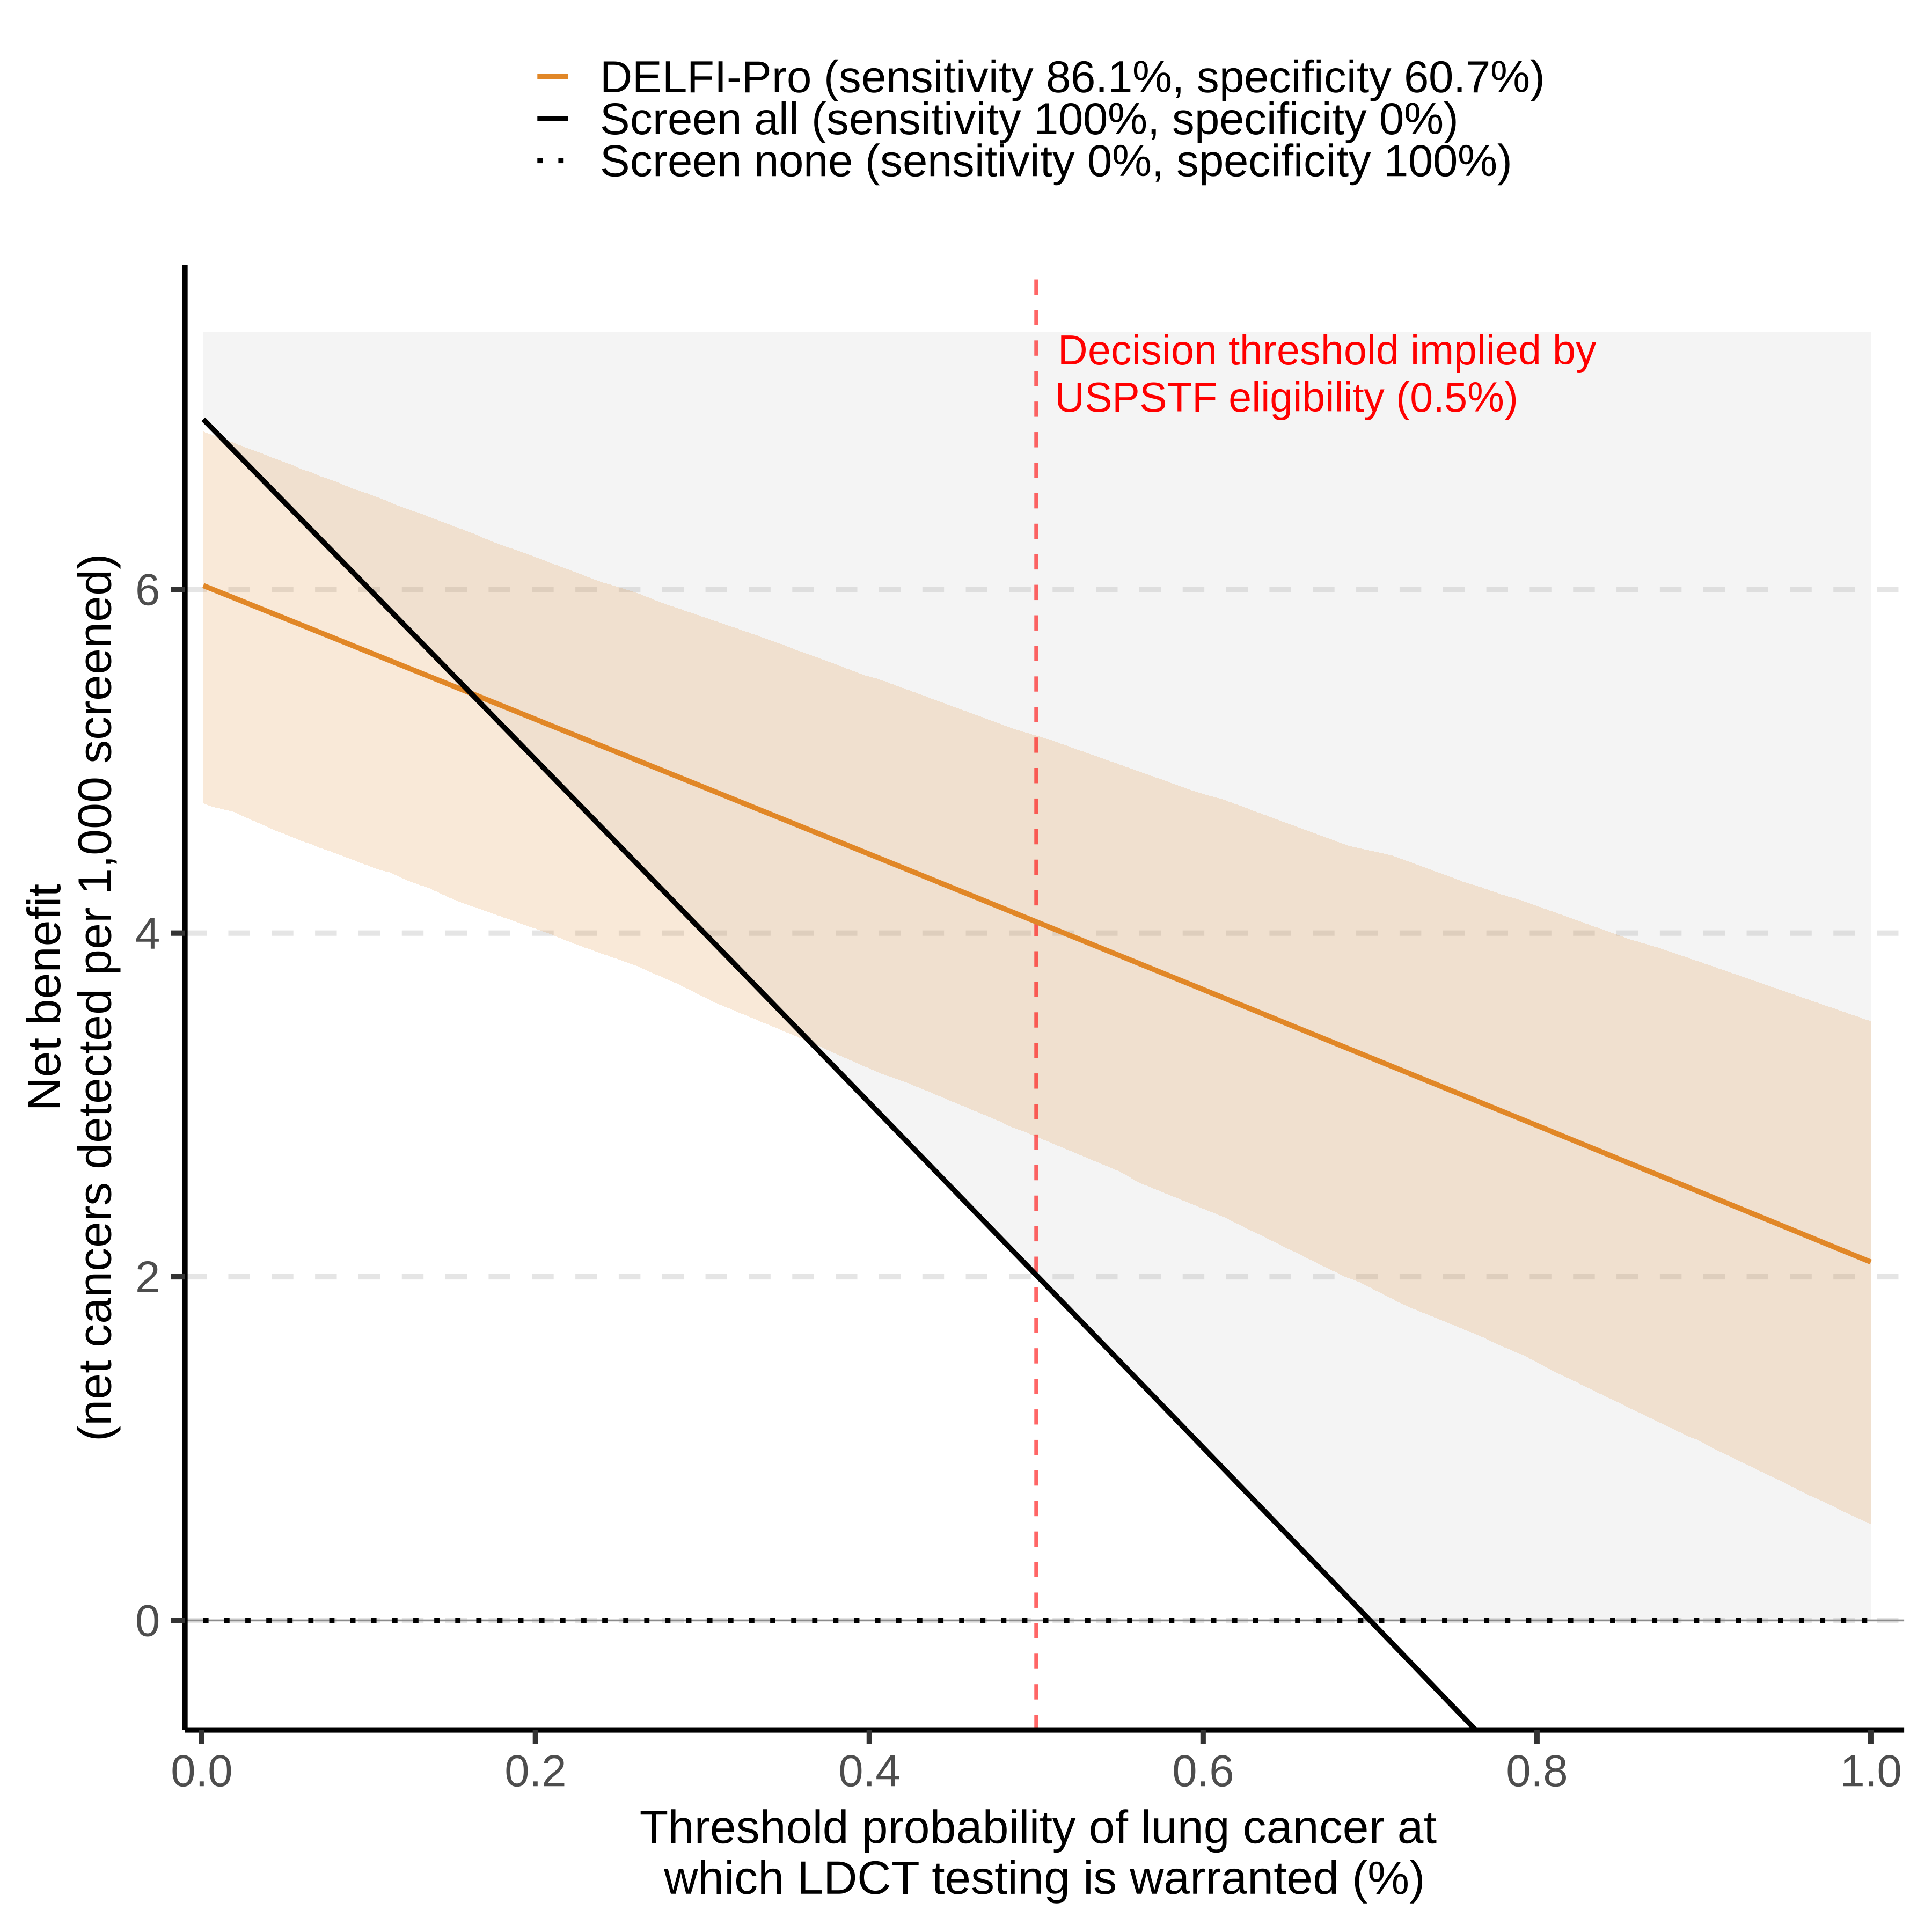

In [26]:
# =====================================================================
# Decision curve analysis (DCA)
# NB = sens*prev - (1-spec)*(1-prev)*(pt/(1-pt))
#   (Vickers & Elkin 2006; Vickers, van Calster, Steyerberg 2019)
#
# Fixed-cutpoint formulation: sens/spec are held constant at the locked
# 60%-specificity operating point, so each curve is linear in pt/(1-pt)
# with intercept prev*sens and slope -(1-spec)*(1-prev).
# "Screen all" is the Vickers treat-all baseline (sens=1, spec=0).
# Each line crosses zero at its own PPV; for screen-all that is the
# prevalence exactly.
#
# Axis range: the two lines cross zero at DIFFERENT points (0.70% for
# screen-all, 1.52% for DELFI-Pro), so there is no single X_MAX that
# keeps both non-negative and still shows the region where DELFI-Pro
# is beneficial and screen-all is not. X_RULE picks which one binds.
# =====================================================================

net_benefit <- function(sens, spec, prevalence, pt) {
    prevalence * sens - (1 - spec) * (1 - prevalence) * (pt / (1 - pt))
}
ppv_from <- function(sens, spec, prevalence) {
    (prevalence * sens) / (prevalence * sens + (1 - spec) * (1 - prevalence))
}

# dca_op is a list, so nrow() is NULL and the old stopifnot() passed
# vacuously. Check the fields that are actually used instead.
stopifnot(is.list(dca_op),
          all(c("sens_wt", "spec", "boot") %in% names(dca_op)),
          exists("PREV"))

SENS <- dca_op$sens_wt
SPEC <- dca_op$spec
USPSTF_THRESHOLD_PCT <- 0.5

# Zero crossings == PPV, exactly
ppv_dp  <- ppv_from(SENS, SPEC, PREV)     # 0.01521
ppv_all <- PREV                           # 0.00700

## ---- axis range ----------------------------------------------------------
X_RULE <- 1   # "delfi" -> X_MAX at DELFI-Pro's zero crossing (1.52%);
                    #            DELFI-Pro stays >= 0 across the panel and
                    #            screen-all exits the bottom at 0.70%
                    # "both"  -> X_MAX at screen-all's zero crossing (0.70%);
                    #            neither line goes negative, but the panel
                    #            stops just past the USPSTF marker
                    # numeric -> set X_MAX directly

X_MAX <- if (is.numeric(X_RULE)) X_RULE else
         switch(X_RULE, delfi = 100 * ppv_dp, both = 100 * ppv_all)

Y_FLOOR <- -0.25    # just below 0, so the zero line and the crossings read
Y_CEIL  <- 7.5      # screen-all starts at 1000*PREV = 7.0
Y_LIM   <- c(Y_FLOOR, Y_CEIL)

pt_seq <- seq(1e-5, X_MAX / 100, length.out = 500)

dp_label  <- sprintf("DELFI-Pro (sensitivity %.1f%%, specificity %.1f%%)",
                     100 * SENS, 100 * SPEC)
all_label <- "Screen all (sensitivity 100%, specificity 0%)"
non_label <- "Screen none (sensitivity 0%, specificity 100%)"

## ---- curves (net benefit x 1000) ----------------------------------------
curves <- bind_rows(
    tibble(pt = pt_seq, nb = 1000 * net_benefit(SENS, SPEC, PREV, pt_seq), strategy = dp_label),
    tibble(pt = pt_seq, nb = 1000 * net_benefit(1,    0,    PREV, pt_seq), strategy = all_label),
    tibble(pt = pt_seq, nb = 0,                                            strategy = non_label)
) %>% mutate(strategy = factor(strategy, levels = c(dp_label, all_label, non_label)))

nb_boot <- apply(dca_op$boot, 1,
                 function(r) 1000 * net_benefit(r["sens_wt"], r["spec"], PREV, pt_seq))
model_band <- tibble(pt = pt_seq,
                     lo = apply(nb_boot, 1, quantile, 0.025),
                     hi = apply(nb_boot, 1, quantile, 0.975))

# Region above max(screen all, screen none): where any test must live
opportunity <- tibble(
    pt   = pt_seq,
    ymin = pmax(1000 * net_benefit(1, 0, PREV, pt_seq), 0),
    ymax = Y_CEIL
)

## ---- plot ----------------------------------------------------------------
strategy_colors <- setNames(c(model_colors[["DELFI-Pro"]], "black", "black"),
                            c(dp_label, all_label, non_label))
strategy_lty    <- setNames(c("solid", "solid", "dotted"),
                            c(dp_label, all_label, non_label))

fig_dca <- ggplot() +
    geom_ribbon(data = opportunity, aes(100 * pt, ymin = ymin, ymax = ymax),
                fill = "grey70", alpha = 0.14) +
    geom_ribbon(data = model_band, aes(100 * pt, ymin = lo, ymax = hi),
                fill = model_colors[["DELFI-Pro"]], alpha = 0.18) +
    geom_hline(yintercept = 0, colour = "grey55", linewidth = 0.4) +
    geom_vline(xintercept = USPSTF_THRESHOLD_PCT, colour = "red",
               linewidth = 0.8, linetype = "dashed", alpha = 0.6) +
    annotate("text", x = USPSTF_THRESHOLD_PCT, y = Y_CEIL,
             label = "Decision threshold implied by\nUSPSTF eligibility (0.5%)",
             colour = "red", size = 6.5, hjust = -0.04, vjust = 1.05, lineheight = 0.95) +
    geom_line(data = curves, aes(100 * pt, nb, colour = strategy, linetype = strategy),
              linewidth = 1.1) +
    scale_colour_manual(values = strategy_colors, name = NULL) +
    scale_linetype_manual(values = strategy_lty, name = NULL) +
    scale_x_continuous("Threshold probability of lung cancer at \nwhich LDCT testing is warranted (%)",
                       breaks = scales::pretty_breaks(n = 6),
                       expand = expansion(mult = c(0.01, 0.02))) +
    scale_y_continuous("Net benefit\n(net cancers detected per 1,000 screened)") +
    coord_cartesian(xlim = c(0, X_MAX), ylim = Y_LIM) +
    theme_classic(base_size = 25) +
    theme(legend.position = "top", legend.direction = "vertical",
          axis.title.x = element_text(size = 21),
          axis.title.y = element_text(size = 21),
          panel.grid.major.y = element_line(colour = "gray90", linetype = "dashed"))

options(repr.plot.width = 12, repr.plot.height = 12, repr.plot.res = 300)

fig_dca

cat(sprintf(
"DELFI-Pro: intercept (prev*sens) = %.6f, slope -(1-spec)(1-prev) = %.6f, zero at pt = %.4f%%
Screen all: intercept = %.6f, slope = %.6f, zero at pt = %.4f%% (= prevalence)
X_RULE = %s -> x-axis 0 to %.4f%%
  DELFI-Pro at X_MAX: %+.4f net cancers/1,000   [>= 0 unless X_RULE overshoots]
  Screen all at X_MAX: %+.4f net cancers/1,000
  Screen-all leaves the panel (crosses 0) at pt = %.4f%%\n",
    PREV * SENS, -(1 - SPEC) * (1 - PREV), 100 * ppv_dp,
    PREV, -(1 - PREV), 100 * ppv_all,
    as.character(X_RULE), X_MAX,
    1000 * net_benefit(SENS, SPEC, PREV, X_MAX / 100),
    1000 * net_benefit(1,    0,    PREV, X_MAX / 100),
    100 * ppv_all))

ggsave("../../outputs/Extended/Ext-Data-Fig-10-DCA_DELFI-Pro_TRAINING.png",
       plot = fig_dca, width = 11, height = 10, dpi = 600)

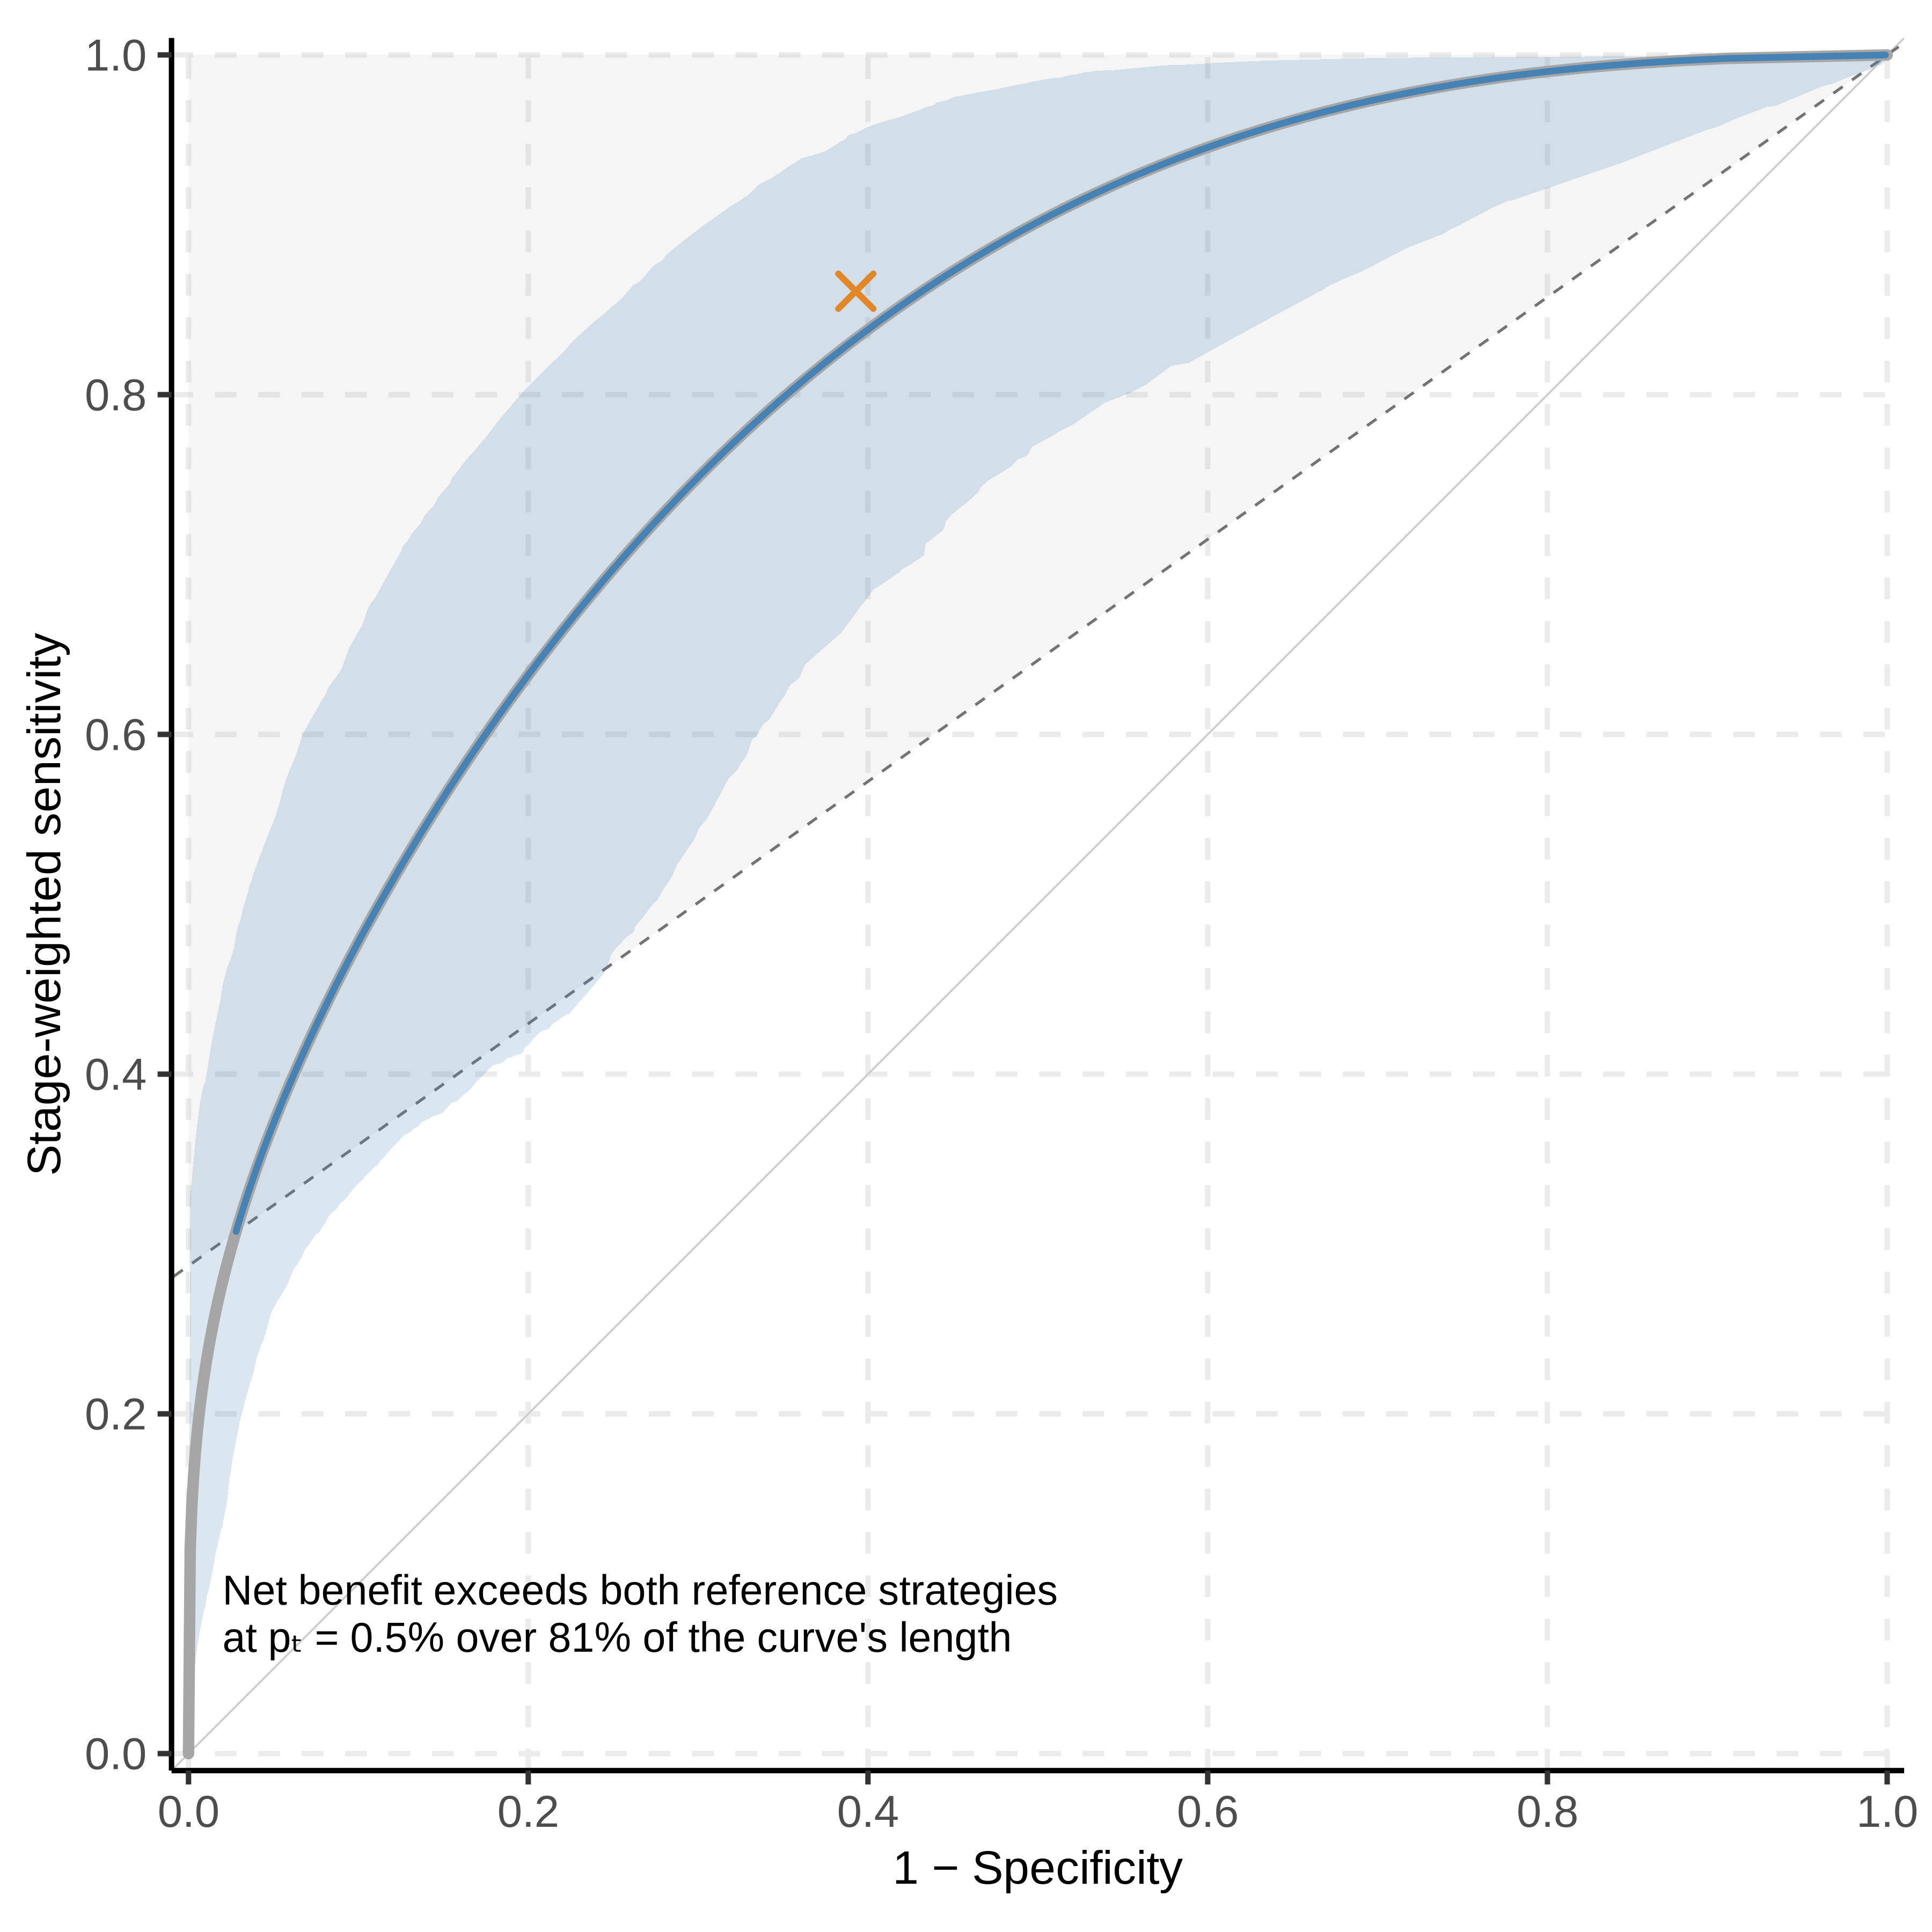

In [27]:
# =====================================================================
# ROC with net-benefit region (Extended Data Fig. 10f)
# SMOOTHED + BOOTSTRAP CONFIDENCE BAND
#
# At threshold probability pt, a test with (sens, spec) beats BOTH
# reference strategies iff  sens > a + b*FPR, where
#   w = pt/(1-pt),  a = max(prev - (1-prev)w, 0)/prev,  b = (1-prev)w/prev
# The boundary is an exact straight line; the shaded region above it is
# where any screening test must live to be worth using at this pt.
# Note a + b = 1 whenever prev > (1-prev)w: the boundary passes through
# (1,1) by construction, i.e. screen-all sits exactly on it. That is an
# identity, not a validation -- the DCA cross-check below is the check.
#
# The curve is stage-weighted AND smoothed:
#   1. one ROC per stage (shared controls, cases = that stage only)
#   2. pROC::smooth() each -> a smooth sens_s(FPR)
#   3. sens_wt(FPR) = sum_s w_s * sens_s(FPR)  on a common FPR grid
# Every stage shares the same control set, so the FPR axis is common
# and the weighted sum is the stage-weighted ROC. Binormal smoothing
# operates on the ROC coordinates, so it is invariant to any monotone
# transformation of the scores.
#
# The band is a stratified nonparametric bootstrap: controls resampled
# as a block, cases resampled WITHIN stage so the weights keep their
# meaning across replicates (same rationale as
# ppv_npv_holdout_bootstrap). The whole pipeline -- ROC, smooth,
# weighted sum -- is re-run inside each replicate, so the band carries
# both sampling variability and the variability of the smoother itself.
# It is POINTWISE at each FPR, not a simultaneous band.
#
# (0,0) and (1,1) stay gray by convention -- screen-none and screen-all.
# =====================================================================

PT_ROC        <- 0.005
STAGE_W       <- c(I = 0.546, II = 0.075, III = 0.218, IV = 0.160)
SMOOTH_METHOD <- "binormal"   # "binormal" | "density" | "none" (= empirical step)
N_GRID        <- 1001         # FPR grid resolution
FRAC_MEASURE  <- "arc"        # "arc" = fraction of curve length; "fpr" = fraction of FPR range
BAND_B        <- 1000         # bootstrap replicates for the band (200 for a quick look)
BAND_CONF     <- 0.95

ROC_SOURCE <- if (!is.null(names(overall.list)) && "DELFI-Pro" %in% names(overall.list)) {
    overall.list[["DELFI-Pro"]]
} else overall.list[[3]]
stopifnot(!is.null(ROC_SOURCE), nrow(dca_op) == 1, exists("PREV"))

## ---- net-benefit boundary ------------------------------------------------
w      <- PT_ROC / (1 - PT_ROC)
nb_ref <- max(PREV - (1 - PREV) * w, 0)
a_int  <- nb_ref / PREV
b_slp  <- (1 - PREV) * w / PREV

ctrl   <- ROC_SOURCE %>% filter(!is.na(score), class == "No cancer")
case   <- ROC_SOURCE %>% filter(!is.na(score), class == "Cancer",
                                stage %in% names(STAGE_W))
stages <- intersect(names(STAGE_W), unique(case$stage))
wts    <- STAGE_W[stages] / sum(STAGE_W[stages])

fpr_grid <- seq(0, 1, length.out = N_GRID)

## ---- the whole curve as one reusable function ----------------------------
# Returns stage-weighted sensitivity on fpr_grid, or NA if a replicate
# degenerates (e.g. a resampled stage ends up all one class).
weighted_curve <- function(ctrl_df, case_df) {
    m <- try(vapply(stages, function(s) {
        d <- bind_rows(ctrl_df, filter(case_df, stage == s))
        r <- pROC::roc(d$class, d$score, levels = c("No cancer", "Cancer"),
                       direction = "<", quiet = TRUE)

        rs <- if (SMOOTH_METHOD == "none") r else
            tryCatch(suppressWarnings(pROC::smooth(r, method = SMOOTH_METHOD)),
                     error = function(e) r)   # fall back to empirical for this stage

        xy <- tibble(x = 1 - rs$specificities, y = rs$sensitivities) %>%
            filter(is.finite(x), is.finite(y)) %>%
            arrange(x, y)
        xy <- bind_rows(tibble(x = 0, y = 0), xy, tibble(x = 1, y = 1))

        approx(xy$x, xy$y, xout = fpr_grid, ties = max, rule = 2)$y
    }, numeric(N_GRID)), silent = TRUE)

    if (inherits(m, "try-error")) return(rep(NA_real_, N_GRID))

    s <- as.numeric(m %*% as.numeric(wts))
    s <- cummax(pmin(pmax(s, 0), 1))    # clamp + enforce monotonicity
    s[1] <- 0; s[N_GRID] <- 1           # pin the conventional endpoints
    s
}

sens_wt <- weighted_curve(ctrl, case)

roc_df <- tibble(fpr = fpr_grid, sens_wt = sens_wt) %>%
    mutate(boundary   = a_int + b_slp * fpr,
           beneficial = sens_wt > boundary & fpr > 0 & fpr < 1,
           run        = cumsum(beneficial != lag(beneficial, default = first(beneficial))))

## ---- stratified bootstrap band -------------------------------------------
set.seed(2024)
band_time <- system.time({
    band_mat <- replicate(BAND_B, {
        ctrl_b <- ctrl[sample.int(nrow(ctrl), replace = TRUE), ]
        case_b <- case %>%                      # stratified: within stage
            group_by(stage) %>%
            slice_sample(prop = 1, replace = TRUE) %>%
            ungroup()
        weighted_curve(ctrl_b, case_b)
    })
})

n_fail <- sum(apply(band_mat, 2, function(v) any(is.na(v))))
band_a <- (1 - BAND_CONF) / 2

band_df <- tibble(
    fpr = fpr_grid,
    lo  = apply(band_mat, 1, quantile, probs = band_a,     na.rm = TRUE),
    hi  = apply(band_mat, 1, quantile, probs = 1 - band_a, na.rm = TRUE)
)

## ---- how much of the curve beats both reference strategies ---------------
frac_of <- function(df, measure = FRAC_MEASURE) {
    d <- df %>% mutate(dx = lead(fpr) - fpr,
                       dy = lead(sens_wt) - sens_wt,
                       ds = if (measure == "arc") sqrt(dx^2 + dy^2) else dx) %>%
        filter(!is.na(ds))
    sum(d$ds[d$beneficial]) / sum(d$ds)
}
frac_arc <- frac_of(roc_df, "arc")
frac_fpr <- frac_of(roc_df, "fpr")
frac_lab <- if (FRAC_MEASURE == "arc") frac_arc else frac_fpr

# The beneficial fraction inherits the same uncertainty. Its bootstrap
# distribution is left-skewed and bounded above -- a replicate can lose a
# stretch of beneficial curve but cannot gain much -- so the point estimate
# sits near the upper limit of a percentile interval. Report the median and
# quartiles alongside so the asymmetry is visible rather than looking like a
# bug; consider a BCa interval (boot::boot.ci) if this goes in the paper.
frac_boot <- apply(band_mat, 2, function(v) {
    if (any(is.na(v))) return(NA_real_)
    frac_of(tibble(fpr = fpr_grid, sens_wt = v,
                   beneficial = v > a_int + b_slp * fpr_grid &
                                fpr_grid > 0 & fpr_grid < 1))
})
frac_ci  <- quantile(frac_boot, c(band_a, 1 - band_a), na.rm = TRUE)
frac_qrt <- quantile(frac_boot, c(0.25, 0.50, 0.75),   na.rm = TRUE)

## ---- operating point -----------------------------------------------------
# Plotted as a bare X. Its interval is reported numerically below rather than
# drawn, so the marker does not compete with the band.
op_pt <- tibble(fpr = 1 - dca_op$spec, sens_wt = dca_op$sens_wt)

has_op_boot <- !is.null(dca_op$boot) &&
    all(c("spec", "sens_wt") %in% colnames(dca_op$boot))

if (has_op_boot) {
    ob <- dca_op$boot
    op_ci <- list(
        fpr_lo  = unname(quantile(1 - ob[, "spec"], band_a)),
        fpr_hi  = unname(quantile(1 - ob[, "spec"], 1 - band_a)),
        sens_lo = unname(quantile(ob[, "sens_wt"], band_a)),
        sens_hi = unname(quantile(ob[, "sens_wt"], 1 - band_a))
    )
}

## ---- empirical (unsmoothed) curve, kept only as a check ------------------
roc_emp <- map_dfr(c(Inf, sort(unique(ROC_SOURCE$score), decreasing = TRUE), -Inf),
    function(t) tibble(
        fpr     = mean(ctrl$score >= t),
        sens_wt = sum(wts * vapply(stages,
                       function(s) mean(case$score[case$stage == s] >= t), numeric(1)))
    )) %>%
    bind_rows(tibble(fpr = c(0, 1), sens_wt = c(0, 1))) %>%
    group_by(fpr) %>% summarise(sens_wt = max(sens_wt), .groups = "drop") %>%
    bind_rows(tibble(fpr = 0, sens_wt = 0)) %>%
    arrange(fpr, sens_wt) %>%
    mutate(beneficial = sens_wt > a_int + b_slp * fpr & fpr > 0 & fpr < 1)
frac_arc_emp <- frac_of(roc_emp, "arc")
frac_fpr_emp <- frac_of(roc_emp, "fpr")

## ---- plot ----------------------------------------------------------------
fig_roc_nb <- ggplot() +
    # region above max(screen all, screen none): where a useful test must live
    geom_ribbon(data = tibble(fpr = c(0, 1)) %>% mutate(ymin = a_int + b_slp * fpr),
                aes(fpr, ymin = ymin, ymax = 1), fill = "grey70", alpha = 0.13) +
    geom_abline(slope = 1, intercept = 0, colour = "grey80", linewidth = 0.4) +
    # the boundary itself, faintly
    geom_abline(slope = b_slp, intercept = a_int,
                colour = "grey45", linetype = "dashed", linewidth = 0.6) +
    # bootstrap band, under the curve
    geom_ribbon(data = band_df, aes(fpr, ymin = lo, ymax = hi),
                fill = "steelblue", alpha = 0.20) +
    # full curve in gray, then the beneficial stretch redrawn in colour
    geom_line(data = roc_df, aes(fpr, sens_wt),
              colour = "grey65", linewidth = 2.4, lineend = "round") +
    geom_line(data = filter(roc_df, beneficial),
              aes(fpr, sens_wt, group = run),
              colour = "steelblue", linewidth = 1.4, lineend = "round") +
    # DCA operating point
    geom_point(data = op_pt, aes(fpr, sens_wt), shape = 4, size = 6, stroke = 2,
               colour = model_colors[["DELFI-Pro"]]) +
    annotate("text", x = 0.02, y = 0.06, hjust = 0, vjust = 0,
             size = 6.5, lineheight = 0.95,
             label = sprintf("Net benefit exceeds both reference strategies\nat p\u209C = %.1f%% over %.0f%% of the curve's length",
                             100 * PT_ROC, 100 * frac_lab)) +
    scale_x_continuous("1 \u2212 Specificity", breaks = seq(0, 1, 0.2),
                       expand = expansion(mult = 0.01)) +
    scale_y_continuous("Stage-weighted sensitivity", breaks = seq(0, 1, 0.2),
                       expand = expansion(mult = 0.01)) +
    coord_fixed(xlim = c(0, 1), ylim = c(0, 1)) +
    theme_classic(base_size = 25) +
    theme(axis.title = element_text(size = 21),
          panel.grid.major = element_line(colour = "gray92", linetype = "dashed"))

fig_roc_nb

In [29]:
ggsave("../../outputs/Extended/Ext-Data-Fig-10-Fig_ROC_NetBenefit_Region.png",
       plot = fig_roc_nb, width = 13, height = 9, dpi = 600)

In [ ]:
# Done #